In [1]:
!pip install xgboost


In [2]:
!pip install statsmodels


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from sklearn.tree import plot_tree

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 110)
pd.set_option("display.max_rows", 25970)


In [5]:
# Read an Excel file into a DataFrame using pandas

df = pd.read_excel("/content/drive/MyDrive/UMBCDATA/RT2733808 Financial aid stdnt Success analysis Final Sp2025.xlsx")


In [6]:
# Display the first 5 rows of the DataFrame to get a quick look at the data
df.head()


,StudentKey,EmployeeID,MatricTermdescription,MatricAcademicYear,MatricStatusOfficialDescr,MatricGenderIPEDS,MatricIPEDSEthnicity,Zipcode,MatricResidence,Graduated,Yrs_To_Deg,Sem_To_Deg,Plan1_1,Plan1_2,Plan1_3,Plan1_4,Plan1_5,Plan1_6,Plan1_7,Plan1_8,Plan1_9,Plan1_10,Plan1_11,Plan1_12,Plan1_13,Plan1_14,Plan1_15,Plan1_16,Deg_8,Deg_10,Deg_12,LastSTEMType,LastrptgPlanShortDescr,Sem1_FTPT,Sem2_FTPT,Sem3_FTPT,Sem4_FTPT,Sem5_FTPT,Sem6_FTPT,Sem7_FTPT,Sem8_FTPT,Sem9_FTPT,Sem10_FTPT,Sem11_FTPT,Sem12_FTPT,Sem13_FTPT,Sem14_FTPT,Sem15_FTPT,Sem16_FTPT,Same_STEM_1_2,Same_STEM_1_21,Same_STEM_1_3,Same_STEM_1_4,Same_STEM_1_5,Same_STEM_1_6,Same_STEM_1_7,Same_STEM_1_8,Same_STEM_1_9,Same_STEM_1_10,Same_STEM_1_11,Same_STEM_1_12,Same_STEM_1_13,Same_STEM_1_14,Same_STEM_1_15,Same_STEM_1_16,Degr4Sem,Degr5Sem,Degr6Sem,Degr7Sem,Degr8Sem,Degr9Sem,Degr10Sem,Degr11Sem,Degr12Sem,Degr13Sem,Degr14Sem,Degr15Sem,Degr16Sem,Y1Need,Y2Need,Y3Need,Y4Need,Y5Need,Y6Need,Y1GrantAmount,Y2GrantAmount,Y3GrantAmount,Y4GrantAmount,Y5GrantAmount,Y6GrantAmount,Y1MeritAmount,Y2MeritAmount,Y3MeritAmount,Y4MeritAmount,Y5MeritAmount,Y6MeritAmount,Y1ScholarProgram,Y1ProgramAmount,Y2ScholarProgram,Y2ProgramAmount,Y3ScholarProgram,Y3ProgramAmount,Y4ScholarProgram,Y4ProgramAmount,Y5ScholarProgram,Y5ProgramAmount,Y6ScholarProgram,Y6ProgramAmount
0,282696,3000000818,Fall 2012,2013,New Freshman,Female,Black/African American,21163,On Campus,Yes,4.0,8.0,Mathematics,Mathematics,Mathematics,Mathematics,Mathematics,Mathematics,Mathematics,Mathematics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,STEM Plan,Mathematics,FT,FT,FT,FT,FT,FT,FT,FT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Medium,Medium,Medium,Medium,No Fafsa,No Fafsa,0.0,0.0,0.0,0.0,0.0,0.0,15000.0,15000.0,15000.0,15000.0,0.0,0.0,MEYERHOFF,15000,MEYERHOFF,15000,MEYERHOFF,15000,MEYERHOFF,15000,NaN,0,NaN,0
1,294772,3000158695,Fall 2012,2013,New Freshman,Male,White,21904,On Campus,Yes,4.0,8.0,Bioc & Mol Biol,Bioc & Mol Biol,Bioc & Mol Biol,Chemistry,Chemistry,Chemistry,Chemistry,Chemistry,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,STEM Plan,Chemistry,FT,FT,FT,FT,FT,FT,FT,FT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,No Fafsa,No Fafsa,No Fafsa,No Fafsa,No Fafsa,No Fafsa,0.0,0.0,0.0,0.0,0.0,0.0,18000.0,18000.0,18000.0,15000.0,0.0,0.0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
2,217735,3000173487,Fall 2012,2013,New Freshman,Female,White,21042,On Campus,Yes,4.0,8.0,Mech Eng,Mech Eng,Mech Eng,Mech Eng,Mech Eng,Mech Eng,Mech Eng,Mech Eng,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,STEM Plan,Mech Eng,FT,FT,FT,FT,FT,FT,FT,FT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Medium,No Fafsa,No Fafsa,No Fafsa,No Fafsa,No Fafsa,0.0,0.0,0.0,0.0,0.0,0.0,15000.0,15000.0,15000.0,15000.0,0.0,0.0,CWIT,15000,CWIT,15000,CWIT,15000,CWIT,15000,NaN,0,NaN,0
3,305144,3000175797,Fall 2012,2013,New Freshman,Male,Black/African American,20794,On Campus,Yes,4.0,8.0,Mech Eng,Mech Eng,Mech Eng,Mech Eng,Mech Eng,Mech Eng,Mech Eng,Mech Eng,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,STEM Plan,Mech Eng,FT,FT,FT,FT,FT,FT,FT,FT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,No Fafsa,No Fafsa,No Fafsa,No Fafsa,No Fafsa,No Fafsa,0.0,0.0,0.0,0.0,0.0,0.0,15000.0,15000.0,15000.0,15000.0,0.0,0.0,MEYERHOFF,15000,MEYERHOFF,15000,MEYERHOFF,15000,MEYERHOFF,15000,NaN,0,NaN,0
4,304109,3000183293,Fall 2012,2013,New Freshman,Male,White,20619,On Campus,Yes,4.0,8.0,Bioc & Mol Biol,Bioc & Mol Biol,Bioc & Mol Biol,Bioc & Mol Biol,Bioc & Mol Biol,Bioc & Mol Biol,Bioc & Mol Biol,Bioc & Mol Biol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,STEM Plan,Bioc & Mol Biol,FT,FT,FT,FT,FT,FT,FT,FT,NaN,NaN,Na

In [7]:
# Returns (rows, columns) of the DataFrame
df.shape


(25960, 108)

# Output: (25960, 108) → 25,960 rows and 108 columns

In [8]:
# Filter only 'New Freshman' students
freshman_df = df[df['MatricStatusOfficialDescr'] == 'New Freshman']

print(freshman_df.shape)

print(freshman_df.head())


(15954, 108)
   StudentKey  EmployeeID MatricTermdescription  MatricAcademicYear  \
0      282696  3000000818             Fall 2012                2013   
1      294772  3000158695             Fall 2012                2013   
2      217735  3000173487             Fall 2012                2013   
3      305144  3000175797             Fall 2012                2013   
4      304109  3000183293             Fall 2012                2013   

  MatricStatusOfficialDescr MatricGenderIPEDS    MatricIPEDSEthnicity Zipcode  \
0              New Freshman            Female  Black/African American   21163   
1              New Freshman              Male                   White   21904   
2              New Freshman            Female                   White   21042   
3              New Freshman              Male  Black/African American   20794   
4              New Freshman              Male                   White   20619   

  MatricResidence Graduated  Yrs_To_Deg  Sem_To_Deg          Plan1_1  \
0

In [9]:
# Define specific columns to keep from 3 patterns: Plan1_, Sem, and Same_STEM_1_
plan_keep = [f'Plan1_{i}' for i in range(1, 9)]       # Plan1_1 to Plan1_8
sem_keep = [f'Sem{i}_FTPT' for i in range(1, 9)]      # Sem1_FTPT to Sem8_FTPT
stem_keep = [f'Same_STEM_1_{i}' for i in range(2, 9)] # Same_STEM_1_2 to Same_STEM_1_8


# Flatten all columns to keep from these 3 groups
keep_these = set(plan_keep + sem_keep + stem_keep)

# Now include all columns NOT related to these 3 groups (Plan1_, Sem, Same_STEM)
# unless they're in the keep list
final_columns = [col for col in freshman_df.columns
                 if (not col.startswith(('Plan1_', 'Sem', 'Same_STEM_1_')) or col in keep_these)]

# Create the trimmed DataFrame
freshman_trimmed_df = freshman_df[final_columns]

# Display result
print(freshman_trimmed_df.shape)
print(freshman_trimmed_df.head())


(15954, 82)
   StudentKey  EmployeeID MatricTermdescription  MatricAcademicYear  \
0      282696  3000000818             Fall 2012                2013   
1      294772  3000158695             Fall 2012                2013   
2      217735  3000173487             Fall 2012                2013   
3      305144  3000175797             Fall 2012                2013   
4      304109  3000183293             Fall 2012                2013   

  MatricStatusOfficialDescr MatricGenderIPEDS    MatricIPEDSEthnicity Zipcode  \
0              New Freshman            Female  Black/African American   21163   
1              New Freshman              Male                   White   21904   
2              New Freshman            Female                   White   21042   
3              New Freshman              Male  Black/African American   20794   
4              New Freshman              Male                   White   20619   

  MatricResidence Graduated  Yrs_To_Deg          Plan1_1          Plan1_2 

# **Cleaning Data**

In [10]:
# Calculate percentage of missing values for each column
null_percentage = (freshman_trimmed_df.isnull().sum() / len(freshman_trimmed_df)) * 100

# Keep only columns with missing values, sorted from highest to lowest
null_percentage = null_percentage[null_percentage > 0].sort_values(ascending=False)

# Show columns with missing data and their % of nulls
print(null_percentage)


Y6ScholarProgram    99.981196
Y5ScholarProgram    99.492290
Y4ScholarProgram    95.906983
Y3ScholarProgram    95.211232
Y2ScholarProgram    93.594083
Y1ScholarProgram    92.873261
Degr16Sem           66.798295
Degr15Sem           60.028833
Degr14Sem           59.922277
Yrs_To_Deg          53.955121
Degr13Sem           51.886674
Deg_12              51.798922
Degr12Sem           51.798922
Plan1_8             50.338473
Sem8_FTPT           50.325937
Sem7_FTPT           46.333208
Plan1_7             46.333208
Degr11Sem           44.170741
Deg_10              44.120597
Degr10Sem           44.120597
Plan1_6             36.906105
Sem6_FTPT           36.906105
Degr9Sem            36.530024
Deg_8               36.429735
Degr8Sem            36.429735
Sem5_FTPT           35.213740
Plan1_5             35.213740
Degr7Sem            27.748527
Same_STEM_1_8       27.748527
Degr6Sem            27.598095
Same_STEM_1_7       27.598095
Plan1_4             25.172371
Sem4_FTPT           25.172371
Sem3_FTPT 

In [11]:
# Find column names with more than 50% missing values
columns_to_drop = null_percentage[null_percentage > 50].index

# Drop those columns from the DataFrame
freshman_cleaned_df = freshman_trimmed_df.drop(columns=columns_to_drop)

# Show which columns were dropped and new shape of the DataFrame
print(f"Columns dropped: {list(columns_to_drop)}")
print(freshman_cleaned_df.shape)


Columns dropped: ['Y6ScholarProgram', 'Y5ScholarProgram', 'Y4ScholarProgram', 'Y3ScholarProgram', 'Y2ScholarProgram', 'Y1ScholarProgram', 'Degr16Sem', 'Degr15Sem', 'Degr14Sem', 'Yrs_To_Deg', 'Degr13Sem', 'Deg_12', 'Degr12Sem', 'Plan1_8', 'Sem8_FTPT']
(15954, 67)


In [12]:
# Count missing values per column
null_counts = freshman_cleaned_df.isnull().sum()

# Calculate missing value percentages
null_percentages = (null_counts / len(freshman_cleaned_df)) * 100

# Create a summary DataFrame of null counts and percentages
null_report = pd.DataFrame({
    'Null Count': null_counts,
    'Null Percentage (%)': null_percentages
})

# Keep only columns with missing values, sorted by percentage descending
null_report = null_report[null_report['Null Count'] > 0].sort_values(by='Null Percentage (%)', ascending=False)

# Show the null summary
print(null_report)


               Null Count  Null Percentage (%)
Plan1_7              7392            46.333208
Sem7_FTPT            7392            46.333208
Degr11Sem            7047            44.170741
Degr10Sem            7039            44.120597
Deg_10               7039            44.120597
Plan1_6              5888            36.906105
Sem6_FTPT            5888            36.906105
Degr9Sem             5828            36.530024
Deg_8                5812            36.429735
Degr8Sem             5812            36.429735
Sem5_FTPT            5618            35.213740
Plan1_5              5618            35.213740
Same_STEM_1_8        4427            27.748527
Degr7Sem             4427            27.748527
Degr6Sem             4403            27.598095
Same_STEM_1_7        4403            27.598095
Sem4_FTPT            4016            25.172371
Plan1_4              4016            25.172371
Plan1_3              3327            20.853704
Sem3_FTPT            3327            20.853704
Degr5Sem     

In [13]:
# Fill Plan and Semester columns with 'NA'
plan_sem_cols = [col for col in freshman_cleaned_df.columns if col.startswith('Plan1_') or col.startswith('Sem')]
freshman_cleaned_df[plan_sem_cols] = freshman_cleaned_df[plan_sem_cols].fillna('NA')

# Fill degree-related columns with 0
deg_cols = [col for col in freshman_cleaned_df.columns if col.startswith('Degr') or col.startswith('Deg_')]
freshman_cleaned_df[deg_cols] = freshman_cleaned_df[deg_cols].fillna(0)

# Fill Same_STEM columns with 0
stem_cols = [col for col in freshman_cleaned_df.columns if col.startswith('Same_STEM_')]
freshman_cleaned_df[stem_cols] = freshman_cleaned_df[stem_cols].fillna(0)

# Fill missing Zipcode values with the most frequent one (mode)
if freshman_cleaned_df['Zipcode'].isnull().sum() > 0:
    zipcode_mode = freshman_cleaned_df['Zipcode'].mode()[0]
    freshman_cleaned_df['Zipcode'] = freshman_cleaned_df['Zipcode'].fillna(zipcode_mode)


In [14]:
null_report = freshman_cleaned_df.isnull().sum()
null_report = null_report[null_report > 0]
print(null_report)


Series([], dtype: int64)


In [15]:
# Create 'totalsupport' column as sum of all grant + merit amounts from Year 1 to Year 6
freshman_cleaned_df['totalsupport'] = freshman_cleaned_df.loc[:, 'Y1GrantAmount':'Y6MeritAmount'].sum(axis=1)

# Create 'supportedY1': 1 if student received any support in Year 1, else 0
freshman_cleaned_df['supportedY1'] = freshman_cleaned_df.apply(
    lambda x: 1 if (x['Y1GrantAmount'] + x['Y1MeritAmount']) != 0 else 0, axis=1
)

# Create 'supported': 1 if student received any support in any year, else 0
freshman_cleaned_df['supported'] = (freshman_cleaned_df['totalsupport'] != 0).astype(int)

# Count how many students were supported vs not supported
support_counts = freshman_cleaned_df[['supported']].value_counts()
print(support_counts)


supported
1            11970
0             3984
Name: count, dtype: int64


In [16]:
# Define financial need columns for Year 1 to Year 6
need_cols = [f'Y{i}Need' for i in range(1, 7)]

# Create 'In_Need': 'Yes' if any year shows High, Medium, or Low need; else 'No'
freshman_cleaned_df['In_Need'] = freshman_cleaned_df[need_cols].apply(
    lambda row: 'Yes' if any(val in ['High', 'Medium', 'Low'] for val in row) else 'No', axis=1
)

# Count how many students were ever in need vs not
print(freshman_cleaned_df['In_Need'].value_counts())


In_Need
Yes    13151
No      2803
Name: count, dtype: int64


In [17]:
# Define columns for merit-based financial aid (Year 1 to 6)
merit_cols = [f'Y{i}MeritAmount' for i in range(1, 7)]

# Define columns for scholarship program amounts (Year 1 to 6)
program_cols = [f'Y{i}ProgramAmount' for i in range(1, 7)]

# Create 'Got_Merit': 'Yes' if total merit aid > 0, else 'No'
freshman_cleaned_df['Got_Merit'] = freshman_cleaned_df[merit_cols].sum(axis=1).apply(
    lambda x: 'Yes' if x > 0 else 'No'
)

# Create 'Got_Scholarship_Program': 'Yes' if total scholarship program aid > 0, else 'No'
freshman_cleaned_df['Got_Scholar'] = freshman_cleaned_df[program_cols].sum(axis=1).apply(
    lambda x: 'Yes' if x > 0 else 'No'
)


In [18]:
# Get all semester columns that indicate full-time or part-time status
sem_ftpt_cols = [col for col in freshman_cleaned_df.columns if col.startswith('Sem') and col.endswith('_FTPT')]

# Create 'Is_FullTime': 'Yes' if student was full-time ('FT') in any semester, else 'No'
freshman_cleaned_df['Is_FullTime'] = freshman_cleaned_df[sem_ftpt_cols].apply(
    lambda row: 'Yes' if 'FT' in row.values else 'No', axis=1
)


In [19]:
# 1. Identify Plan Columns

# Create a list of major-related columns Plan1_1 to Plan1_7 (if they exist in the DataFrame)
plan_cols = [f'Plan1_{i}' for i in range(1, 8) if f'Plan1_{i}' in freshman_cleaned_df.columns]


# 2. Extract Initial Major

# Function to get the first valid (non-'NA') major declared by a student
def get_first_valid_major(row):
    majors = [m for m in row if m != 'NA']  # filter out 'NA'
    return majors[0] if majors else None   # return first non-'NA' or None

# Apply the function to each row to create 'Initial_Major' column
freshman_cleaned_df['Initial_Major'] = freshman_cleaned_df[plan_cols].apply(get_first_valid_major, axis=1)


# 3. Extract Final Major

# Function to get the last valid (non-'NA') major declared by a student
def get_last_valid_major(row):
    majors = [m for m in row if m != 'NA']
    return majors[-1] if majors else None  # return last non-'NA' or None

# Apply the function to create 'Final_Major' column
freshman_cleaned_df['Final_Major'] = freshman_cleaned_df[plan_cols].apply(get_last_valid_major, axis=1)


# 4. Flag Major Change (Start ≠ End)

# Create a 'Changed_Major' column: 'Yes' if first and last majors differ, else 'No'
freshman_cleaned_df['Changed_Major'] = freshman_cleaned_df.apply(
    lambda x: 'Yes' if x['Initial_Major'] and x['Final_Major'] and x['Initial_Major'] != x['Final_Major'] else 'No',
    axis=1
)


# 5. Detect Changes in Middle (Start = End but changed in between)

# Function to check if student changed major in between but returned to original major
def changed_in_middle(row):
    majors = [m for m in row[plan_cols] if m != 'NA']  # get all declared majors
    return 'Yes' if len(set(majors)) > 1 and majors[0] == majors[-1] else 'No'

# Apply function to create 'Changed_In_Middle' column
freshman_cleaned_df['Changed_In_Middle'] = freshman_cleaned_df.apply(changed_in_middle, axis=1)


# ---------------------------
# 6. Count Number of Unique Majors
# ---------------------------

# Create 'Num_Majors': number of distinct (non-'NA') majors student declared
freshman_cleaned_df['Num_Majors'] = freshman_cleaned_df[plan_cols].apply(
    lambda row: len(set([m for m in row if m != 'NA'])), axis=1
)


# 7. Count Number of Major Switches

# Function to count how many times the major changed across semesters
def count_major_switches(row):
    majors = [m for m in row[plan_cols] if m != 'NA']
    # Count how many times adjacent majors differ
    return sum(majors[i] != majors[i+1] for i in range(len(majors)-1))

# Apply the function to create 'Major_Change_Count' column
freshman_cleaned_df['Major_Change_Count'] = freshman_cleaned_df.apply(count_major_switches, axis=1)


In [20]:
# Verify at least one student with different initial and final major
changed_df = freshman_cleaned_df[freshman_cleaned_df['Changed_Major'] == 'Yes']
print("Sample rows where Changed_Major = 'Yes':")
print(changed_df[['Initial_Major', 'Final_Major', 'Changed_Major']].head())


Sample rows where Changed_Major = 'Yes':
      Initial_Major          Final_Major Changed_Major
1   Bioc & Mol Biol            Chemistry           Yes
5          Biol Sci  UG Std: Exploratory           Yes
10      Environ Sci             Biol Sci           Yes
14         Comp Sci            Economics           Yes
17      Environ Sci              English           Yes


In [21]:
# Filter after correction
students_changed_major = freshman_cleaned_df[freshman_cleaned_df['Changed_Major'] == 'Yes']

# Display
print(students_changed_major[['StudentKey', 'Initial_Major', 'Final_Major', 'Changed_Major',
                              'Changed_In_Middle', 'Num_Majors', 'Major_Change_Count'] + plan_cols].head(10))


    StudentKey    Initial_Major          Final_Major Changed_Major  \
1       294772  Bioc & Mol Biol            Chemistry           Yes   
5       313830         Biol Sci  UG Std: Exploratory           Yes   
10      313833      Environ Sci             Biol Sci           Yes   
14      306169         Comp Sci            Economics           Yes   
17      303834      Environ Sci              English           Yes   
19      313835         Comp Sci          Indiv Study           Yes   
20      304267         Comp Eng             Comp Sci           Yes   
22      306178         Comp Eng             Info Sys           Yes   
24      303835         Comp Eng             Info Sys           Yes   
25      309193         Biol Sci          Mathematics           Yes   

   Changed_In_Middle  Num_Majors  Major_Change_Count          Plan1_1  \
1                 No           2                   1  Bioc & Mol Biol   
5                 No           2                   1         Biol Sci   
10        

In [22]:
freshman_cleaned_df.shape

(15954, 80)

#**Model Building**

In [23]:
# Convert 'Graduated' column to binary: 1 for 'Yes', 0 for 'No'
freshman_cleaned_df['Graduated'] = freshman_cleaned_df['Graduated'].map({'Yes': 1, 'No': 0})


In [24]:
# Function to prepare data for modeling
# Parameters:
#   selected_features: list of column names to use as features
#   scale_numeric: whether to apply standard scaling to numeric columns
def prepare_data(selected_features, scale_numeric=True):

    # Select feature columns (X) and target column (y)
    X = freshman_cleaned_df[selected_features]
    y = freshman_cleaned_df['Graduated']

    # Split data into training and testing sets (80/20 split, stratified by class)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Identify categorical and numerical columns
    categorical_cols = X.select_dtypes(include='object').columns.tolist()
    numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # Define preprocessing pipeline
    if scale_numeric:
        # Scale numeric columns and one-hot encode categorical columns
        preprocessor = ColumnTransformer([
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ])
    else:
        # Only one-hot encode categorical columns; leave numeric columns unchanged
        preprocessor = ColumnTransformer([
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ], remainder='passthrough')  # Keep numeric columns as they are

    # Return train-test splits and preprocessing pipeline
    return X_train, X_test, y_train, y_test, preprocessor, categorical_cols, numerical_cols


In [25]:
my_features = [
     'Changed_Major','supportedY1', 'In_Need', 'Got_Merit', 'Got_Scholar',
    'Is_FullTime', 'totalsupport'
]

In [26]:
# Prepare data using selected features and apply scaling to numeric columns
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, preprocessor_scaled, cat_cols, num_cols = prepare_data(my_features, scale_numeric=True)

# Create a pipeline: preprocessing + Decision Tree classifier (max depth = 4)
tree_scaled = Pipeline([
    ('preprocessor', preprocessor_scaled),                             # Applies scaling and one-hot encoding
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))  # Shallow tree to reduce overfitting
])

# Train the model on the training set
tree_scaled.fit(X_train_scaled, y_train_scaled)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['supportedY1',
                                                   'totalsupport']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Changed_Major', 'In_Need',
                                                   'Got_Merit', 'Got_Scholar',
                                                   'Is_FullTime'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=4, random_state=42))])

Accuracy: 0.6631
ROC AUC: 0.7076
F1 Score: 0.6310


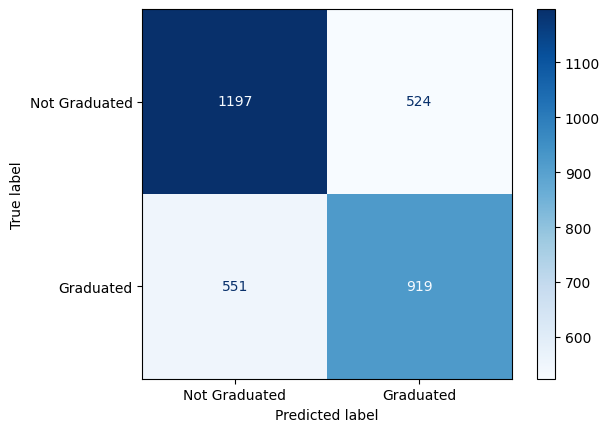

In [27]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Make predictions on the test set
y_pred = tree_scaled.predict(X_test_scaled)

# Get predicted probabilities (for ROC AUC)
y_proba = tree_scaled.predict_proba(X_test_scaled)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test_scaled, y_pred)

# ROC AUC
roc_auc = roc_auc_score(y_test_scaled, y_proba)

# F1 Score
f1 = f1_score(y_test_scaled, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test_scaled, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Graduated', 'Graduated'])

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"F1 Score: {f1:.4f}")

# Show confusion matrix
disp.plot(cmap='Blues')


In [28]:
# Prepare data without scaling numeric features
X_train_raw, X_test_raw, y_train_raw, y_test_raw, preprocessor_raw, cat_cols_raw, num_cols_raw = prepare_data(my_features, scale_numeric=False)

# Create pipeline: preprocessing (only one-hot encoding) + Decision Tree classifier
tree_raw = Pipeline([
    ('preprocessor', preprocessor_raw),                                # Only encodes categorical features
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))  # Decision Tree with limited depth
])

# Train the model on raw (unscaled) data
tree_raw.fit(X_train_raw, y_train_raw)


/usr/local/lib/python3.11/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Changed_Major', 'In_Need',
                                                   'Got_Merit', 'Got_Scholar',
                                                   'Is_FullTime'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=4, random_state=42))])

Accuracy (raw): 0.6628
ROC AUC (raw): 0.7075
F1 Score (raw): 0.6307


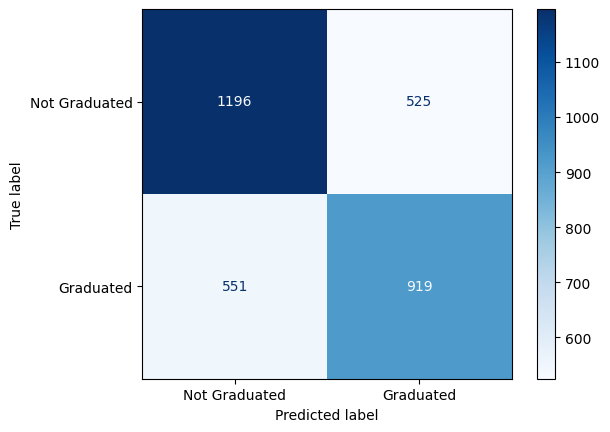

In [29]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Make predictions
y_pred_raw = tree_raw.predict(X_test_raw)

# Predicted probabilities for ROC AUC
y_proba_raw = tree_raw.predict_proba(X_test_raw)[:, 1]

# Accuracy
accuracy_raw = accuracy_score(y_test_raw, y_pred_raw)

# ROC AUC
roc_auc_raw = roc_auc_score(y_test_raw, y_proba_raw)

# F1 Score
f1_raw = f1_score(y_test_raw, y_pred_raw)

# Confusion Matrix
cm_raw = confusion_matrix(y_test_raw, y_pred_raw)
disp_raw = ConfusionMatrixDisplay(confusion_matrix=cm_raw, display_labels=['Not Graduated', 'Graduated'])

# Print metrics
print(f"Accuracy (raw): {accuracy_raw:.4f}")
print(f"ROC AUC (raw): {roc_auc_raw:.4f}")
print(f"F1 Score (raw): {f1_raw:.4f}")

# Plot confusion matrix
disp_raw.plot(cmap='Blues')


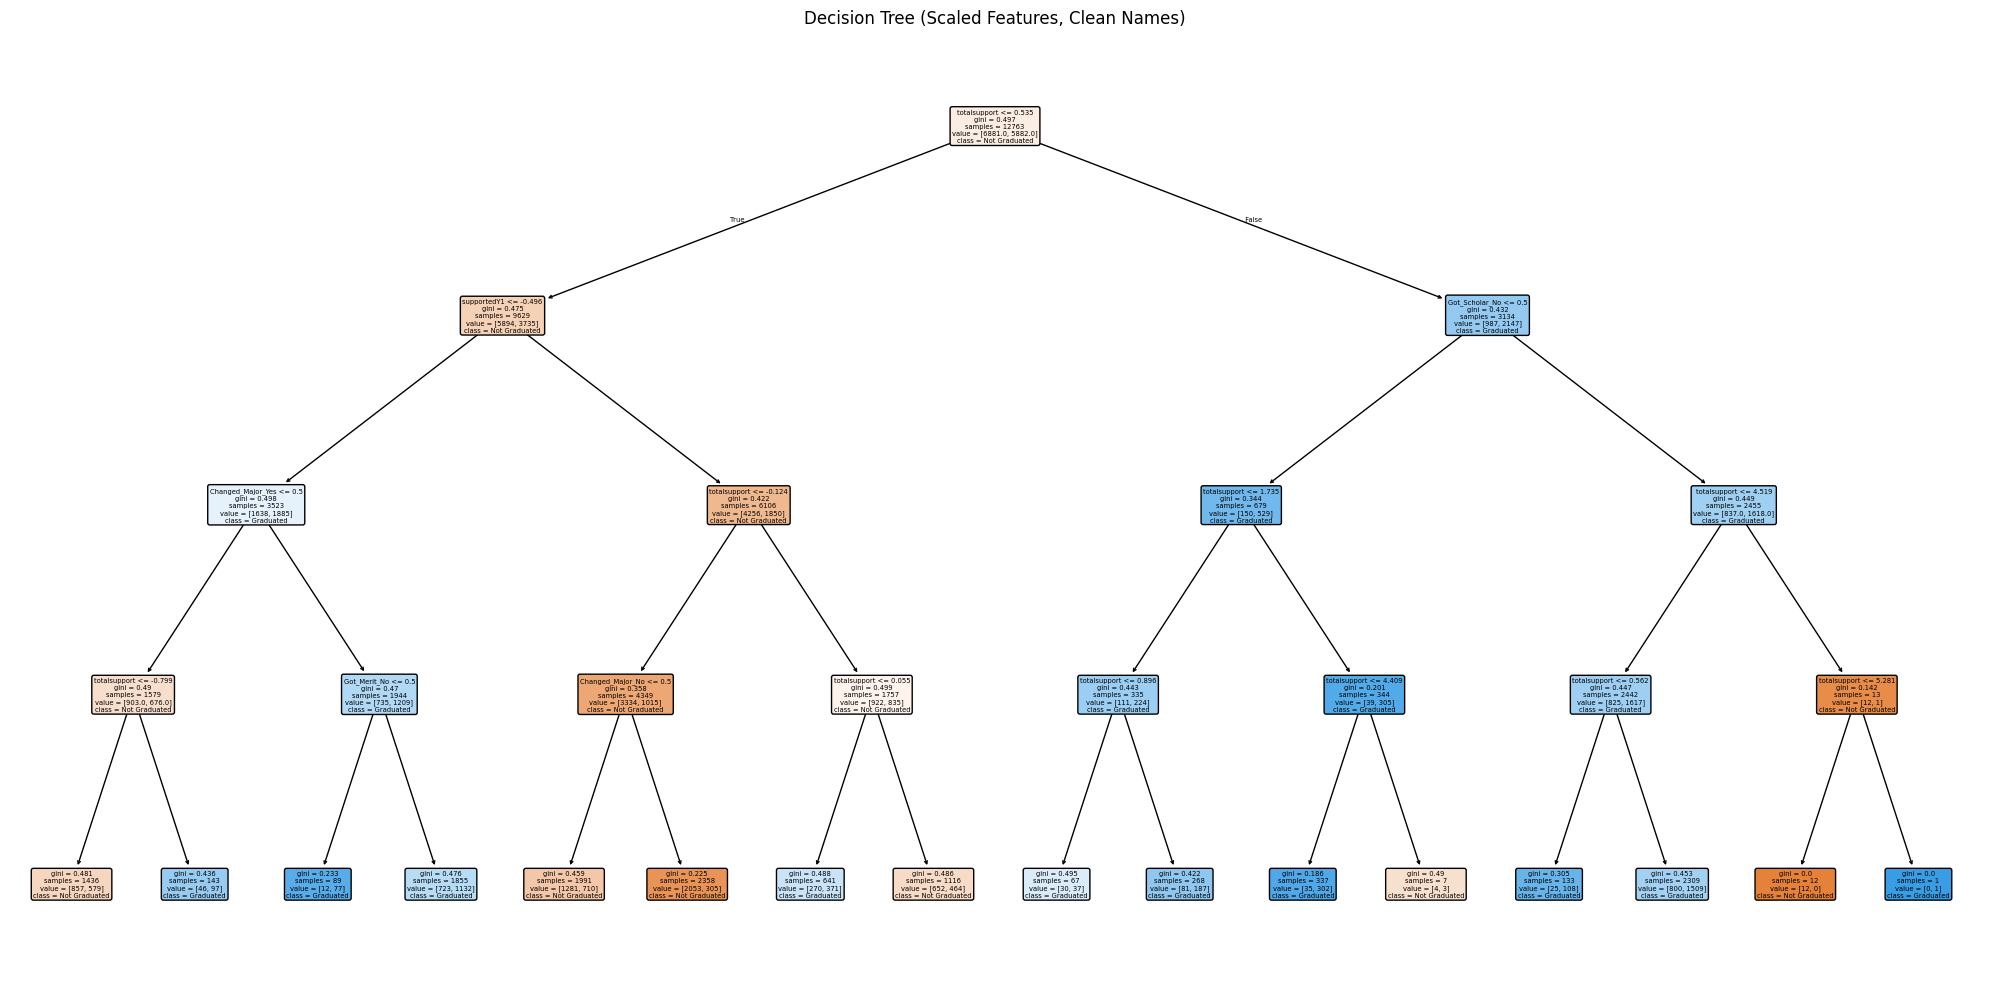

In [30]:
# Clean Feature Names (Scaled)

# Extract clean feature names by removing transformer prefix (e.g., 'num__' or 'cat__')
feature_names_scaled = [
    name.split('__')[-1] for name in tree_scaled.named_steps['preprocessor'].get_feature_names_out()
]

# Plot Scaled Decision Tree with Clean Names

plt.figure(figsize=(20, 10))  # Set figure size

# Plot the decision tree
plot_tree(
    tree_scaled.named_steps['classifier'],  # Decision tree model from pipeline
    feature_names=feature_names_scaled,     # Cleaned feature names
    class_names=["Not Graduated", "Graduated"],  # Target class labels
    filled=True,    # Fill nodes with colors
    rounded=True,   # Round the box corners
    max_depth=4     # Limit depth for readability
)

plt.title("Decision Tree (Scaled Features, Clean Names)")
plt.tight_layout()                      # Prevent label cutoff
plt.savefig("decision_tree_scaled_clean.png", dpi=1000)  # Save high-res image
plt.show()                              # Display the plot


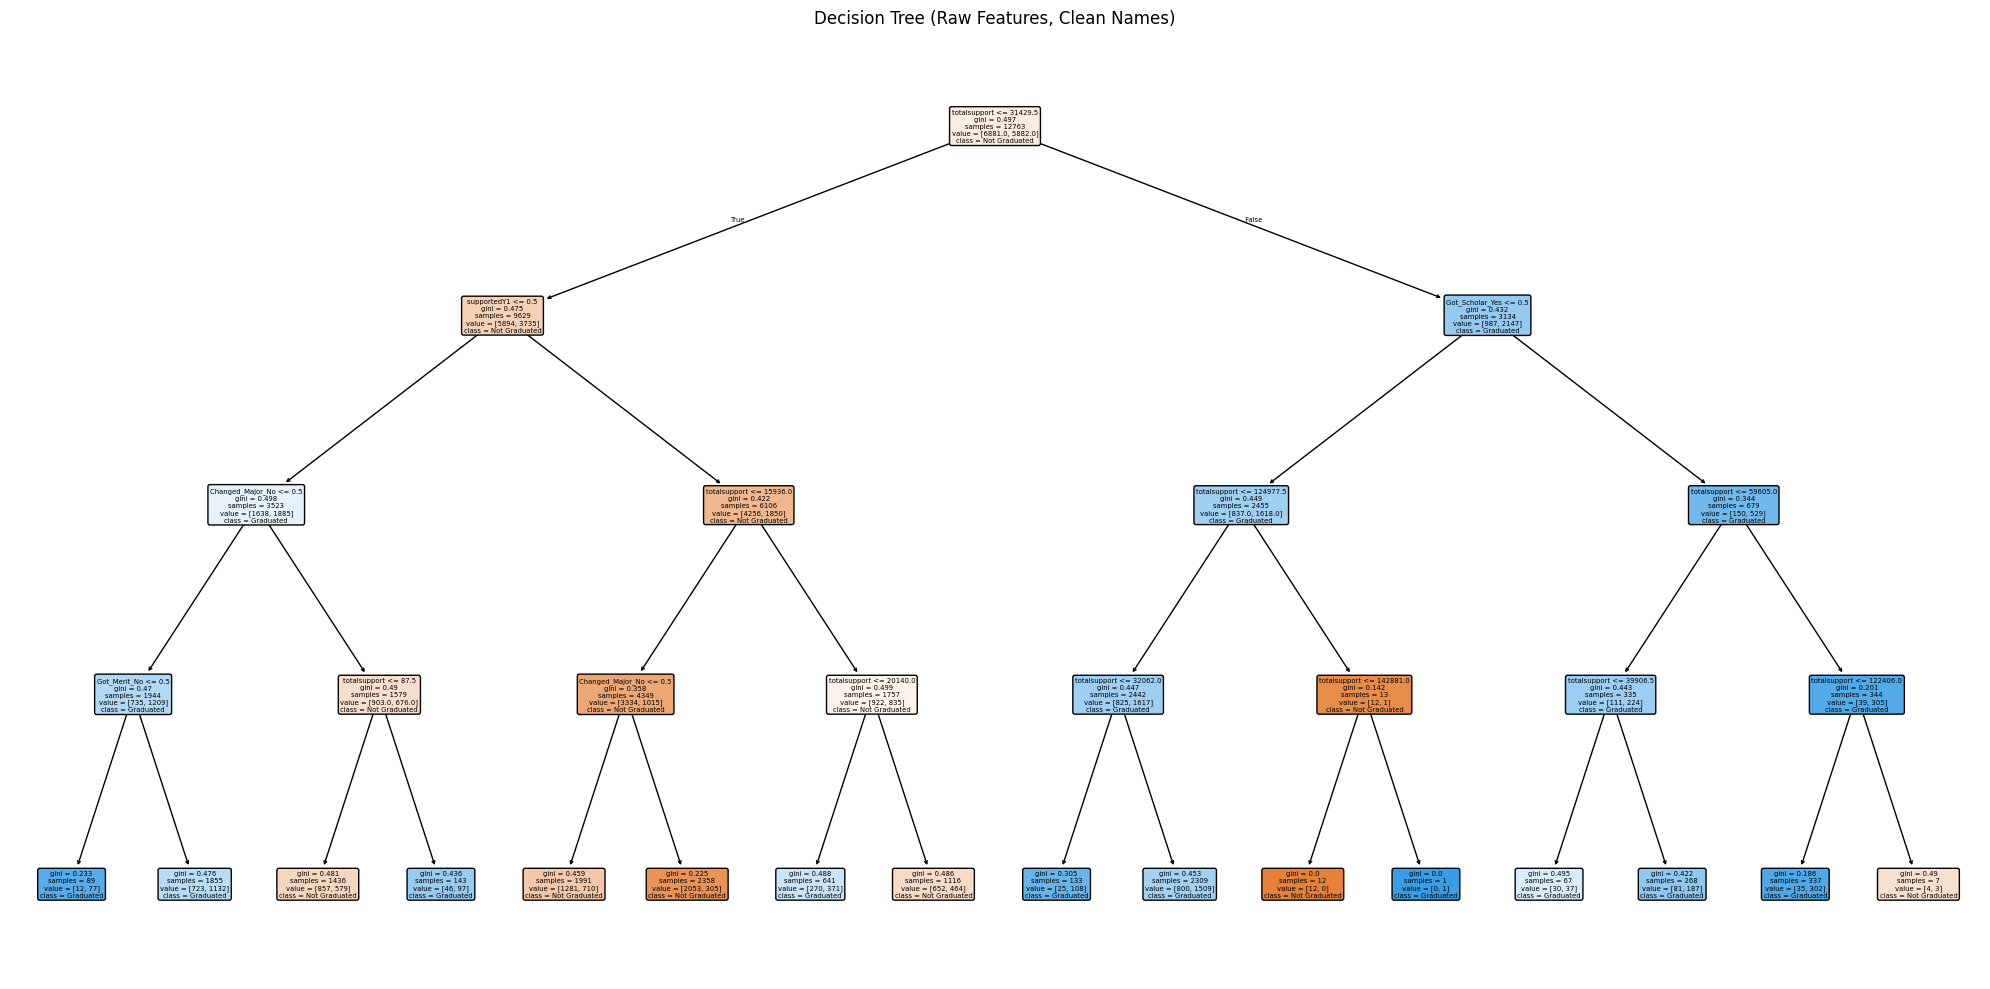

In [31]:

# Clean Feature Names (Raw Features)

# Remove prefixes like 'cat__' from one-hot encoded feature names
feature_names_raw = [
    name.split('__')[-1] for name in tree_raw.named_steps['preprocessor'].get_feature_names_out()
]

# Plot Decision Tree (Raw Features)

plt.figure(figsize=(20, 10))  # Set large figure size for readability

plot_tree(
    tree_raw.named_steps['classifier'],        # Decision tree from the raw pipeline
    feature_names=feature_names_raw,           # Cleaned feature names
    class_names=["Not Graduated", "Graduated"],  # Labels for class outcomes
    filled=True,                               # Color the nodes
    rounded=True,                              # Round box corners
    max_depth=4                                # Limit depth for clarity
)

plt.title("Decision Tree (Raw Features, Clean Names)")
plt.tight_layout()                      # Prevent label cutoff
plt.savefig("decision_tree_raw_clean.png", dpi=1000)  # Save high-res image
plt.show()

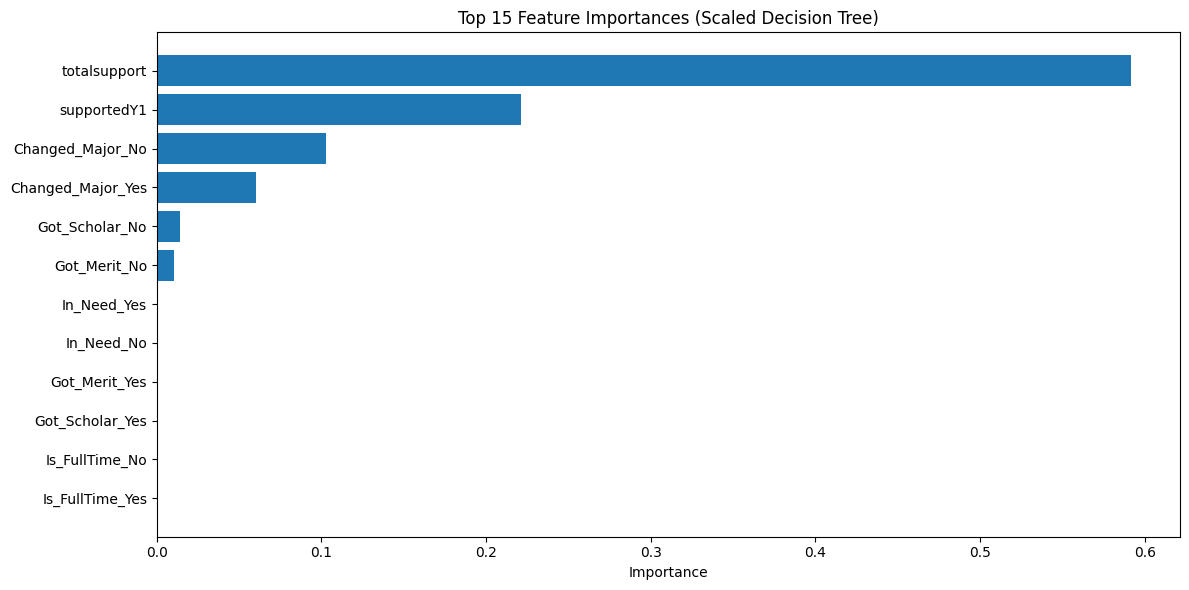

In [32]:


# Get cleaned feature names
feature_names_scaled = [
    name.split('__')[-1] for name in tree_scaled.named_steps['preprocessor'].get_feature_names_out()
]

# Get feature importances
importances_scaled = tree_scaled.named_steps['classifier'].feature_importances_

# Create a DataFrame for plotting
feat_imp_df_scaled = pd.DataFrame({
    'Feature': feature_names_scaled,
    'Importance': importances_scaled
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
plt.barh(feat_imp_df_scaled['Feature'][:15], feat_imp_df_scaled['Importance'][:15])  # Top 15
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Scaled Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


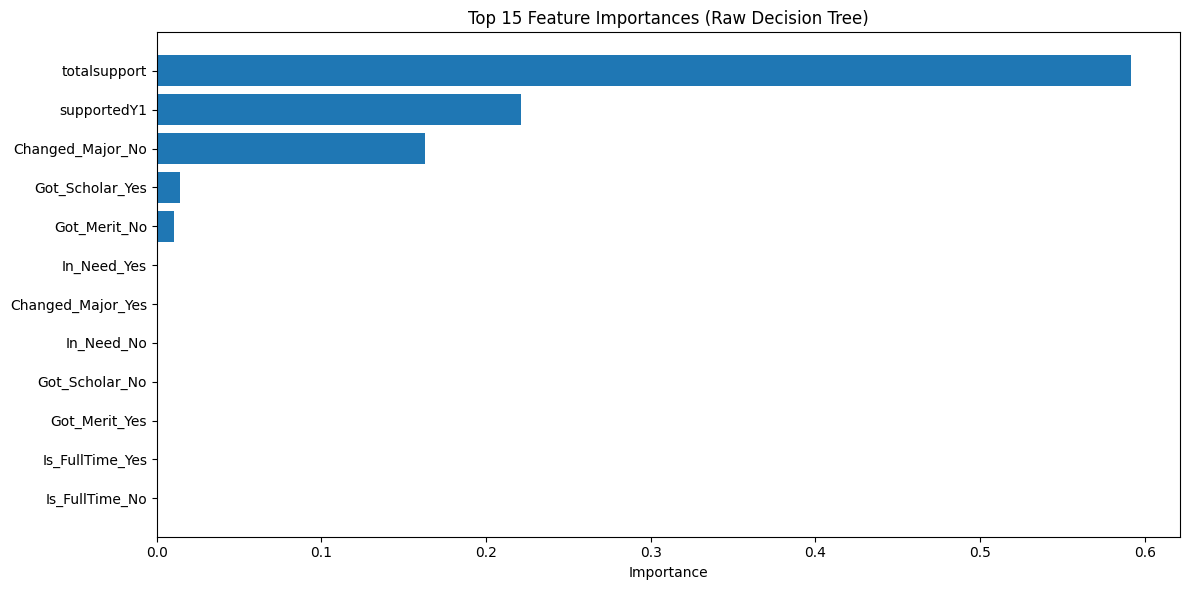

In [33]:
# Get cleaned feature names
feature_names_raw = [
    name.split('__')[-1] for name in tree_raw.named_steps['preprocessor'].get_feature_names_out()
]

# Get feature importances
importances_raw = tree_raw.named_steps['classifier'].feature_importances_

# Create a DataFrame
feat_imp_df_raw = pd.DataFrame({
    'Feature': feature_names_raw,
    'Importance': importances_raw
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
plt.barh(feat_imp_df_raw['Feature'][:15], feat_imp_df_raw['Importance'][:15])  # Top 15
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Raw Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [34]:
from sklearn.tree import export_text

# Get feature names after one-hot encoding or scaling
feature_names_raw = [name.split('__')[-1] for name in tree_raw.named_steps['preprocessor'].get_feature_names_out()]

# Extract the trained decision tree model from the pipeline
decision_tree_model = tree_raw.named_steps['classifier']

# Export the tree structure as readable text
tree_text = export_text(decision_tree_model, feature_names=feature_names_raw)

# Print the human-readable decision tree
print(tree_text)


|--- totalsupport <= 31429.50
|   |--- supportedY1 <= 0.50
|   |   |--- Changed_Major_No <= 0.50
|   |   |   |--- Got_Merit_No <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Got_Merit_No >  0.50
|   |   |   |   |--- class: 1
|   |   |--- Changed_Major_No >  0.50
|   |   |   |--- totalsupport <= 87.50
|   |   |   |   |--- class: 0
|   |   |   |--- totalsupport >  87.50
|   |   |   |   |--- class: 1
|   |--- supportedY1 >  0.50
|   |   |--- totalsupport <= 15936.00
|   |   |   |--- Changed_Major_No <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Changed_Major_No >  0.50
|   |   |   |   |--- class: 0
|   |   |--- totalsupport >  15936.00
|   |   |   |--- totalsupport <= 20140.00
|   |   |   |   |--- class: 1
|   |   |   |--- totalsupport >  20140.00
|   |   |   |   |--- class: 0
|--- totalsupport >  31429.50
|   |--- Got_Scholar_Yes <= 0.50
|   |   |--- totalsupport <= 124977.50
|   |   |   |--- totalsupport <= 32062.00
|   |   |   |   |--- class: 1
|   |   |   |--- totalsu

# **Feature 2**

In [35]:
my_features = [
    'MatricTermdescription', 'MatricAcademicYear', 'MatricGenderIPEDS',
    'MatricIPEDSEthnicity', 'Changed_Major', 'supportedY1',
    'Got_Merit', 'Got_Scholar', 'Is_FullTime', 'totalsupport'
]

In [36]:
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, preprocessor_scaled, cat_cols, num_cols = prepare_data(my_features, scale_numeric=True)
tree_scaled = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))
])
tree_scaled.fit(X_train_scaled, y_train_scaled)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['MatricAcademicYear',
                                                   'supportedY1',
                                                   'totalsupport']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['MatricTermdescription',
                                                   'MatricGenderIPEDS',
                                                   'MatricIPEDSEthnicity',
                                                   'Changed_Major', 'Got_Merit',
                                                   'Got_Scholar',
                                                   'Is_FullTime'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=4, random_state=42))])

Accuracy: 0.8286
ROC AUC: 0.9084
F1 Score: 0.8247


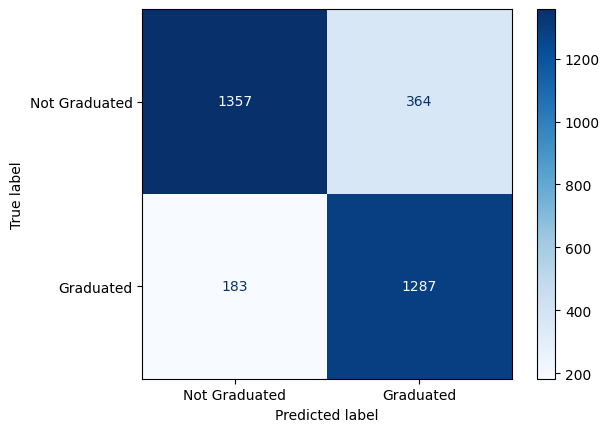

In [37]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Make predictions on the test set
y_pred = tree_scaled.predict(X_test_scaled)

# Get predicted probabilities (for ROC AUC)
y_proba = tree_scaled.predict_proba(X_test_scaled)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test_scaled, y_pred)

# ROC AUC
roc_auc = roc_auc_score(y_test_scaled, y_proba)

# F1 Score
f1 = f1_score(y_test_scaled, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test_scaled, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Graduated', 'Graduated'])

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"F1 Score: {f1:.4f}")

# Show confusion matrix
disp.plot(cmap='Blues')


In [38]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw, preprocessor_raw, cat_cols_raw, num_cols_raw = prepare_data(my_features, scale_numeric=False)
tree_raw = Pipeline([
    ('preprocessor', preprocessor_raw),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))
])
tree_raw.fit(X_train_raw, y_train_raw)


/usr/local/lib/python3.11/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['MatricTermdescription',
                                                   'MatricGenderIPEDS',
                                                   'MatricIPEDSEthnicity',
                                                   'Changed_Major', 'Got_Merit',
                                                   'Got_Scholar',
                                                   'Is_FullTime'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=4, random_state=42))])

Accuracy (raw): 0.8286
ROC AUC (raw): 0.9084
F1 Score (raw): 0.8247


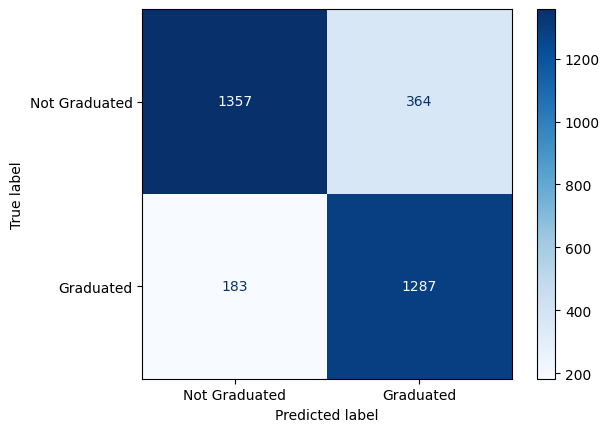

In [39]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Make predictions
y_pred_raw = tree_raw.predict(X_test_raw)

# Predicted probabilities for ROC AUC
y_proba_raw = tree_raw.predict_proba(X_test_raw)[:, 1]

# Accuracy
accuracy_raw = accuracy_score(y_test_raw, y_pred_raw)

# ROC AUC
roc_auc_raw = roc_auc_score(y_test_raw, y_proba_raw)

# F1 Score
f1_raw = f1_score(y_test_raw, y_pred_raw)

# Confusion Matrix
cm_raw = confusion_matrix(y_test_raw, y_pred_raw)
disp_raw = ConfusionMatrixDisplay(confusion_matrix=cm_raw, display_labels=['Not Graduated', 'Graduated'])

# Print metrics
print(f"Accuracy (raw): {accuracy_raw:.4f}")
print(f"ROC AUC (raw): {roc_auc_raw:.4f}")
print(f"F1 Score (raw): {f1_raw:.4f}")

# Plot confusion matrix
disp_raw.plot(cmap='Blues')


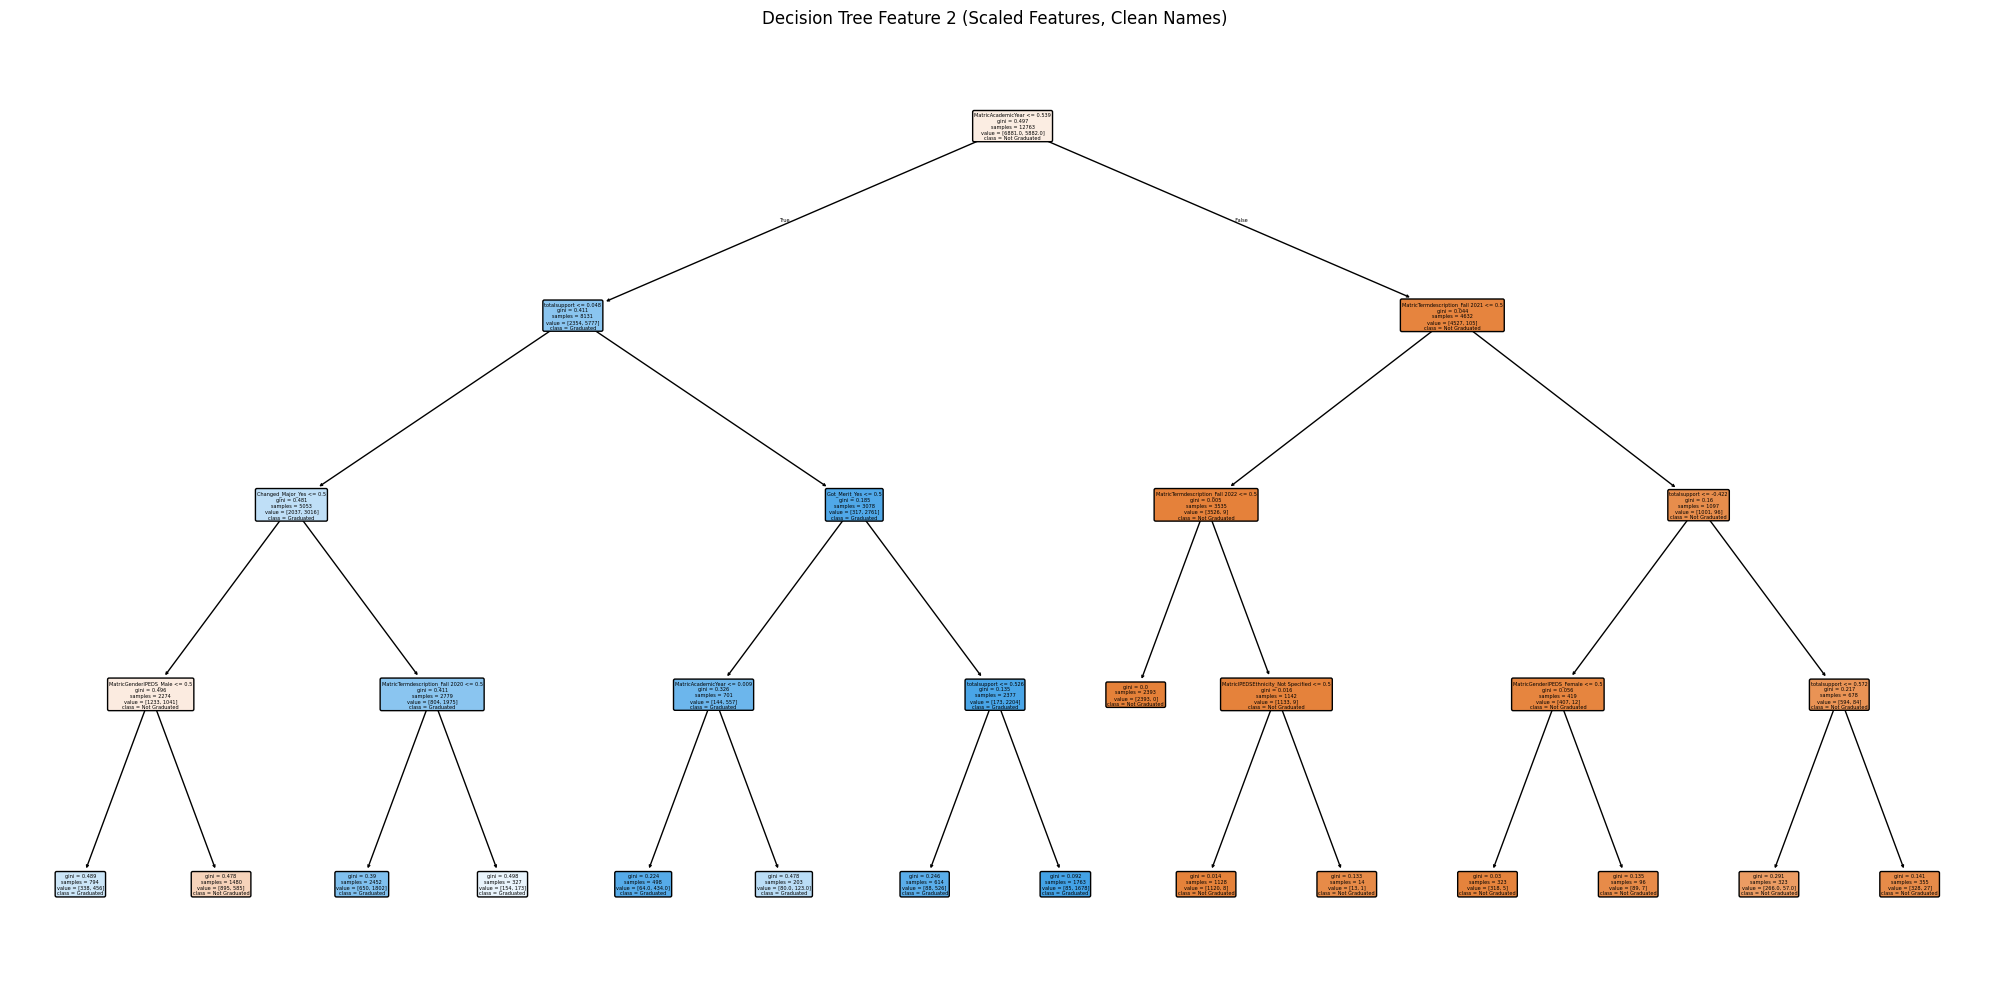

In [40]:
# Clean Feature Names (Scaled)

# Extract clean feature names by removing transformer prefix (e.g., 'num__' or 'cat__')
feature_names_scaled = [
    name.split('__')[-1] for name in tree_scaled.named_steps['preprocessor'].get_feature_names_out()
]

# Plot Scaled Decision Tree with Clean Names

plt.figure(figsize=(20, 10))  # Set figure size

# Plot the decision tree
plot_tree(
    tree_scaled.named_steps['classifier'],  # Decision tree model from pipeline
    feature_names=feature_names_scaled,     # Cleaned feature names
    class_names=["Not Graduated", "Graduated"],  # Target class labels
    filled=True,    # Fill nodes with colors
    rounded=True,   # Round the box corners
    max_depth=4     # Limit depth for readability
)

plt.title("Decision Tree Feature 2 (Scaled Features, Clean Names)")
plt.tight_layout()                      # Prevent label cutoff
plt.savefig("decision_tree_feature2_scaled_clean.png", dpi=1000)  # Save high-res image
plt.show()                              # Display the plot


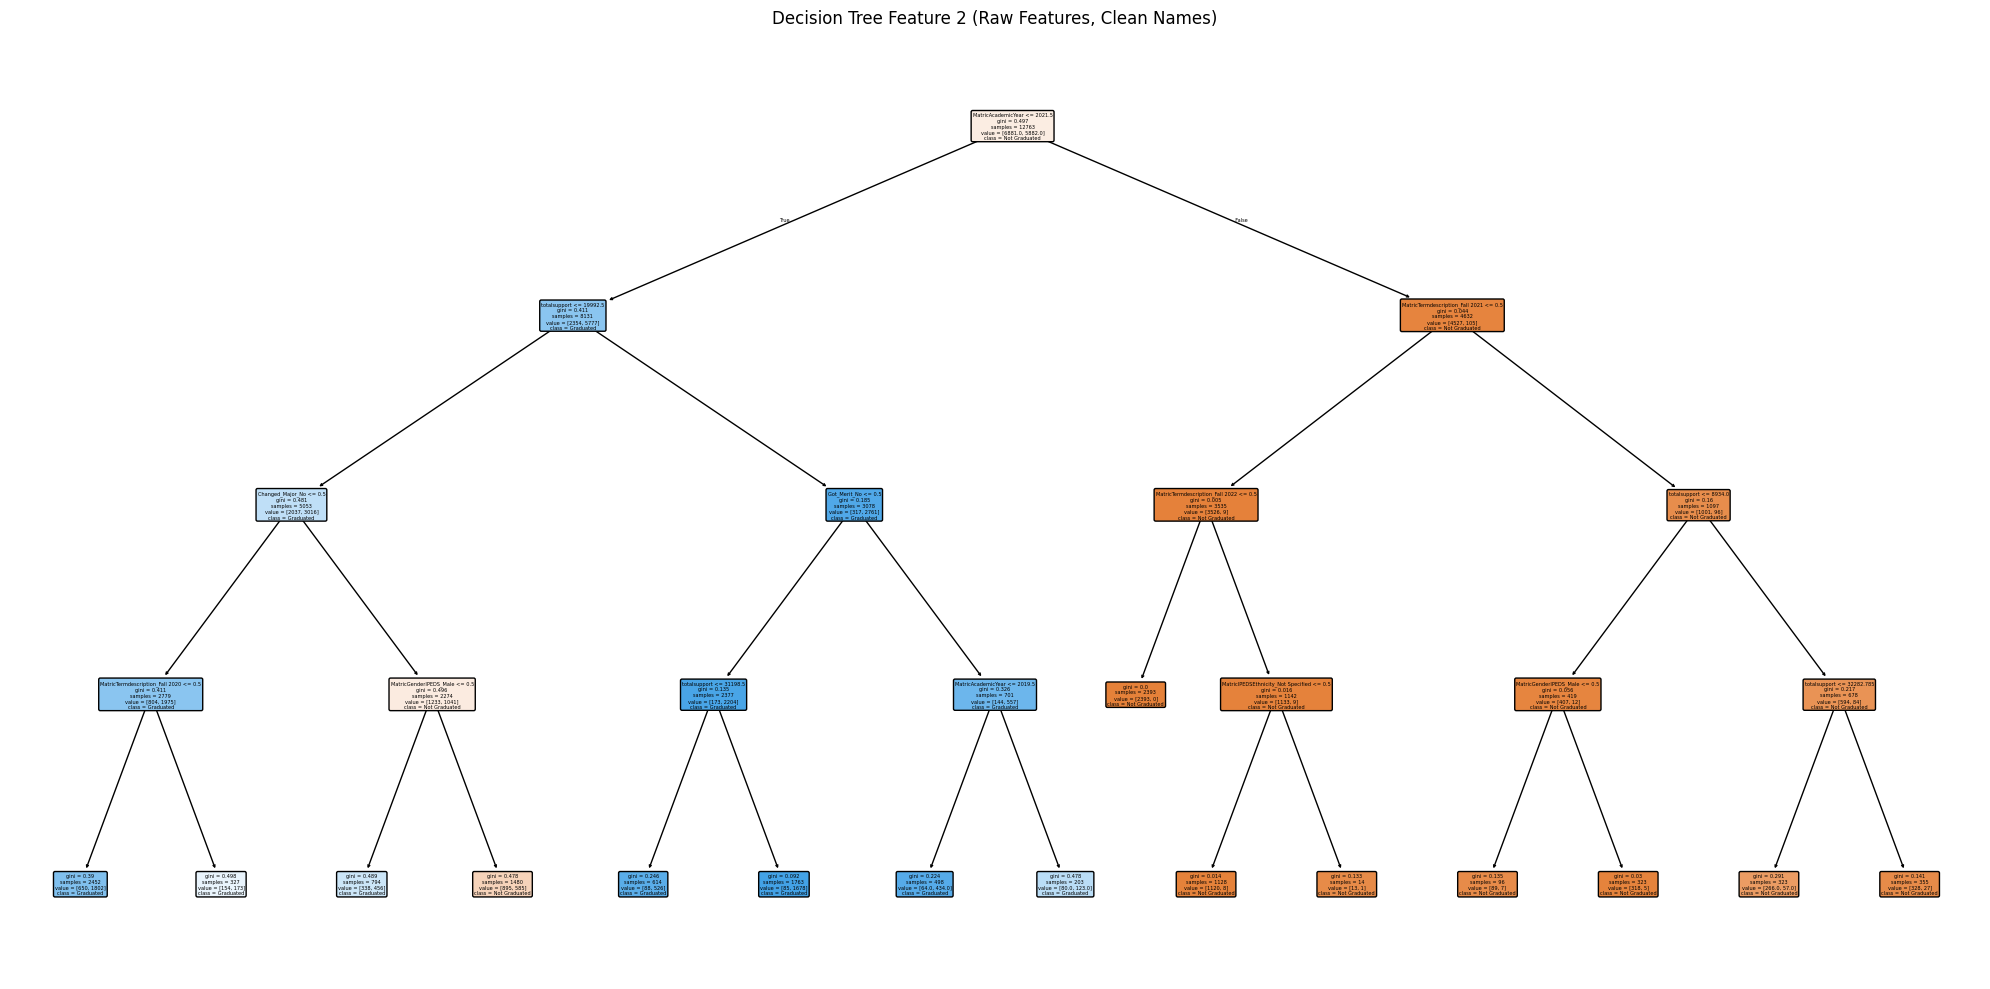

In [41]:

# Clean Feature Names (Raw Features)

# Remove prefixes like 'cat__' from one-hot encoded feature names
feature_names_raw = [
    name.split('__')[-1] for name in tree_raw.named_steps['preprocessor'].get_feature_names_out()
]

# Plot Decision Tree (Raw Features)

plt.figure(figsize=(20, 10))  # Set large figure size for readability

plot_tree(
    tree_raw.named_steps['classifier'],        # Decision tree from the raw pipeline
    feature_names=feature_names_raw,           # Cleaned feature names
    class_names=["Not Graduated", "Graduated"],  # Labels for class outcomes
    filled=True,                               # Color the nodes
    rounded=True,                              # Round box corners
    max_depth=4                                # Limit depth for clarity
)

plt.title("Decision Tree Feature 2 (Raw Features, Clean Names)")
plt.tight_layout()                      # Prevent label cutoff
plt.savefig("decision_tree_raw_clean.png", dpi=1000)  # Save high-res image
plt.show()

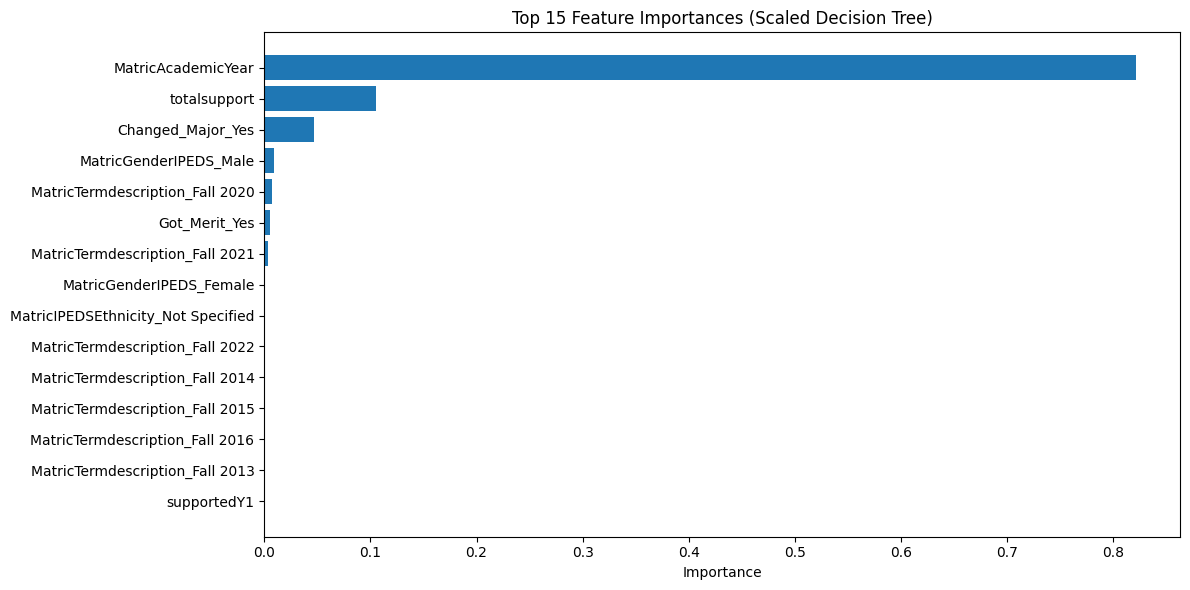

In [42]:


# Get cleaned feature names
feature_names_scaled = [
    name.split('__')[-1] for name in tree_scaled.named_steps['preprocessor'].get_feature_names_out()
]

# Get feature importances
importances_scaled = tree_scaled.named_steps['classifier'].feature_importances_

# Create a DataFrame for plotting
feat_imp_df_scaled = pd.DataFrame({
    'Feature': feature_names_scaled,
    'Importance': importances_scaled
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
plt.barh(feat_imp_df_scaled['Feature'][:15], feat_imp_df_scaled['Importance'][:15])  # Top 15
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Scaled Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


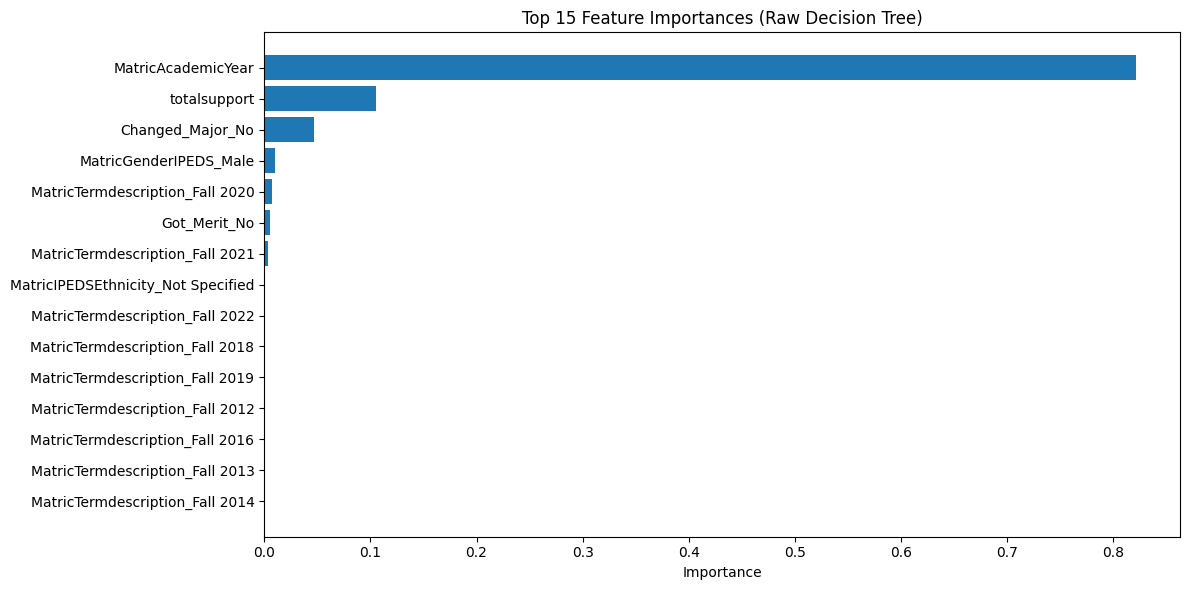

In [43]:
# Get cleaned feature names
feature_names_raw = [
    name.split('__')[-1] for name in tree_raw.named_steps['preprocessor'].get_feature_names_out()
]

# Get feature importances
importances_raw = tree_raw.named_steps['classifier'].feature_importances_

# Create a DataFrame
feat_imp_df_raw = pd.DataFrame({
    'Feature': feature_names_raw,
    'Importance': importances_raw
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
plt.barh(feat_imp_df_raw['Feature'][:15], feat_imp_df_raw['Importance'][:15])  # Top 15
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Raw Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# **students who enrolled on or before 2016**

In [44]:
freshman_cleaned_df['MatricYear'] = freshman_cleaned_df['MatricTermdescription'].str.extract(r'(\d{4})').astype(int)

# Keep only students who started in 2016 or earlier
freshman_cleaned_df = freshman_cleaned_df[freshman_cleaned_df['MatricYear'] <= 2016]


In [45]:
my_features = [
     'Changed_Major','supportedY1', 'In_Need', 'Got_Merit', 'Got_Scholar',
    'Is_FullTime', 'totalsupport'
]

Accuracy (Raw): 0.7711
F1 Score (Raw): 0.8625
ROC AUC (Raw): 0.7678


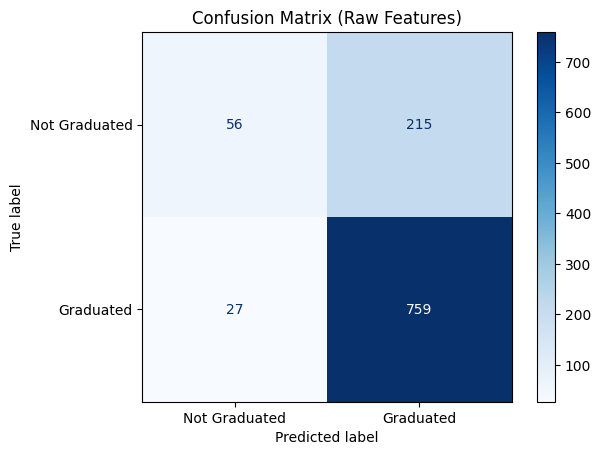

In [46]:
# ----- Prepare Data -----
X_train_raw, X_test_raw, y_train_raw, y_test_raw, preprocessor_raw, cat_cols_raw, num_cols_raw = prepare_data(
    selected_features=my_features,
    scale_numeric=False
)

# ----- Train Pipeline -----
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

tree_raw = Pipeline([
    ('preprocessor', preprocessor_raw),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))
])

tree_raw.fit(X_train_raw, y_train_raw)

# ----- Evaluate Model -----
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

y_pred_raw = tree_raw.predict(X_test_raw)
y_proba_raw = tree_raw.predict_proba(X_test_raw)[:, 1]

print(f"Accuracy (Raw): {accuracy_score(y_test_raw, y_pred_raw):.4f}")
print(f"F1 Score (Raw): {f1_score(y_test_raw, y_pred_raw):.4f}")
print(f"ROC AUC (Raw): {roc_auc_score(y_test_raw, y_proba_raw):.4f}")

cm_raw = confusion_matrix(y_test_raw, y_pred_raw)
ConfusionMatrixDisplay(confusion_matrix=cm_raw, display_labels=["Not Graduated", "Graduated"]).plot(cmap='Blues')
plt.title("Confusion Matrix (Raw Features)")
plt.show()



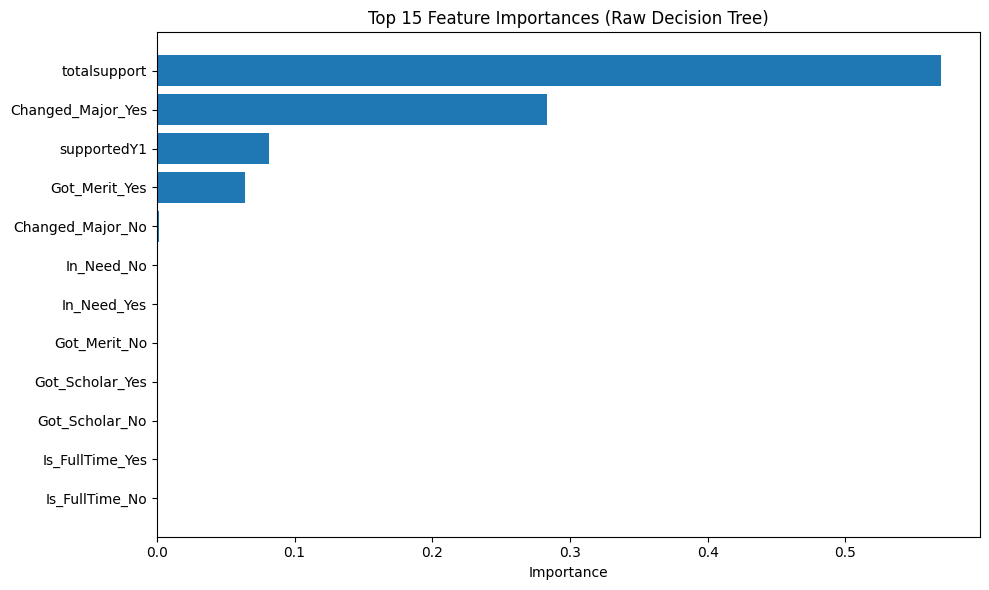

In [47]:


# Get clean feature names
feature_names_raw = [
    name.split('__')[-1] for name in tree_raw.named_steps['preprocessor'].get_feature_names_out()
]

# Get importance scores
importances_raw = tree_raw.named_steps['classifier'].feature_importances_

# Build DataFrame for easy sorting/plotting
feat_imp_df_raw = pd.DataFrame({
    'Feature': feature_names_raw,
    'Importance': importances_raw
}).sort_values(by='Importance', ascending=False)

# Plot Top 15 Features
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df_raw['Feature'][:15], feat_imp_df_raw['Importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Raw Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


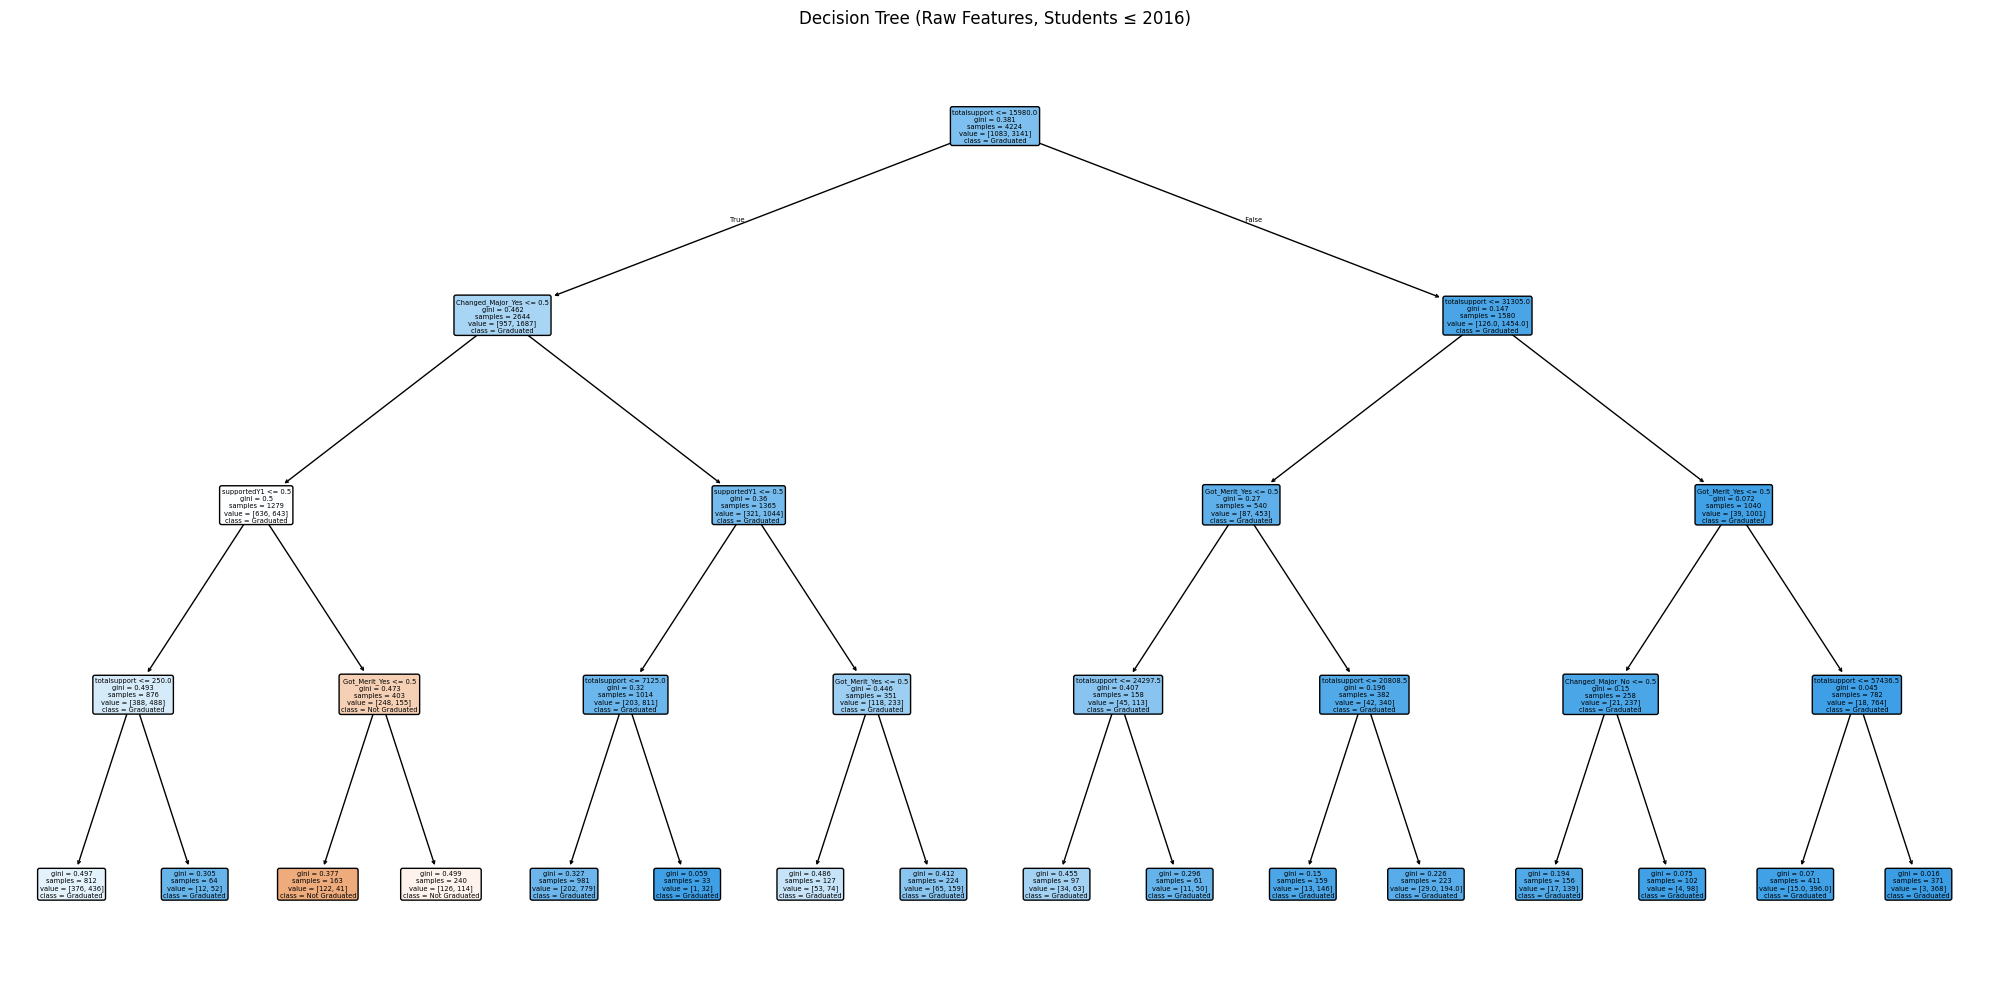

In [48]:
# ----- Plot Tree -----
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

feature_names_raw = [name.split('__')[-1] for name in tree_raw.named_steps['preprocessor'].get_feature_names_out()]

plt.figure(figsize=(20, 10))
plot_tree(
    tree_raw.named_steps['classifier'],
    feature_names=feature_names_raw,
    class_names=["Not Graduated", "Graduated"],
    filled=True,
    rounded=True,
    max_depth=4
)
plt.title("Decision Tree (Raw Features, Students ≤ 2016)")
plt.tight_layout()
plt.savefig("decision_tree_raw_filtered_2016.png", dpi=1000)
plt.show()


Accuracy (Scaled): 0.7711
F1 Score (Scaled): 0.8625
ROC AUC (Scaled): 0.7678


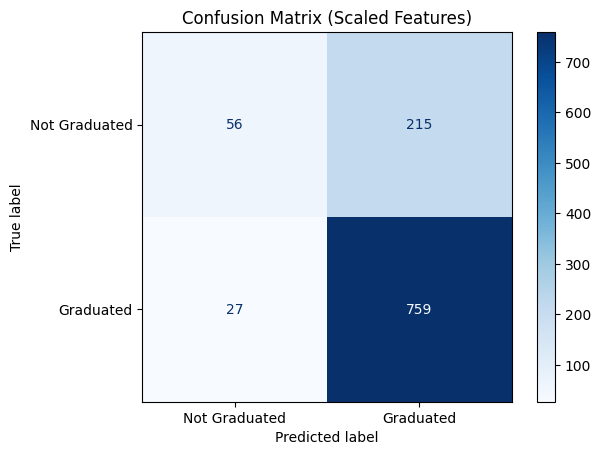

In [49]:
# ----- Prepare Data -----
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, preprocessor_scaled, cat_cols_scaled, num_cols_scaled = prepare_data(
    selected_features=my_features,
    scale_numeric=True
)

# ----- Train Pipeline -----
tree_scaled = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))
])

tree_scaled.fit(X_train_scaled, y_train_scaled)

# ----- Evaluate Model -----
y_pred_scaled = tree_scaled.predict(X_test_scaled)
y_proba_scaled = tree_scaled.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy (Scaled): {accuracy_score(y_test_scaled, y_pred_scaled):.4f}")
print(f"F1 Score (Scaled): {f1_score(y_test_scaled, y_pred_scaled):.4f}")
print(f"ROC AUC (Scaled): {roc_auc_score(y_test_scaled, y_proba_scaled):.4f}")

cm_scaled = confusion_matrix(y_test_scaled, y_pred_scaled)
ConfusionMatrixDisplay(confusion_matrix=cm_scaled, display_labels=["Not Graduated", "Graduated"]).plot(cmap='Blues')
plt.title("Confusion Matrix (Scaled Features)")
plt.show()




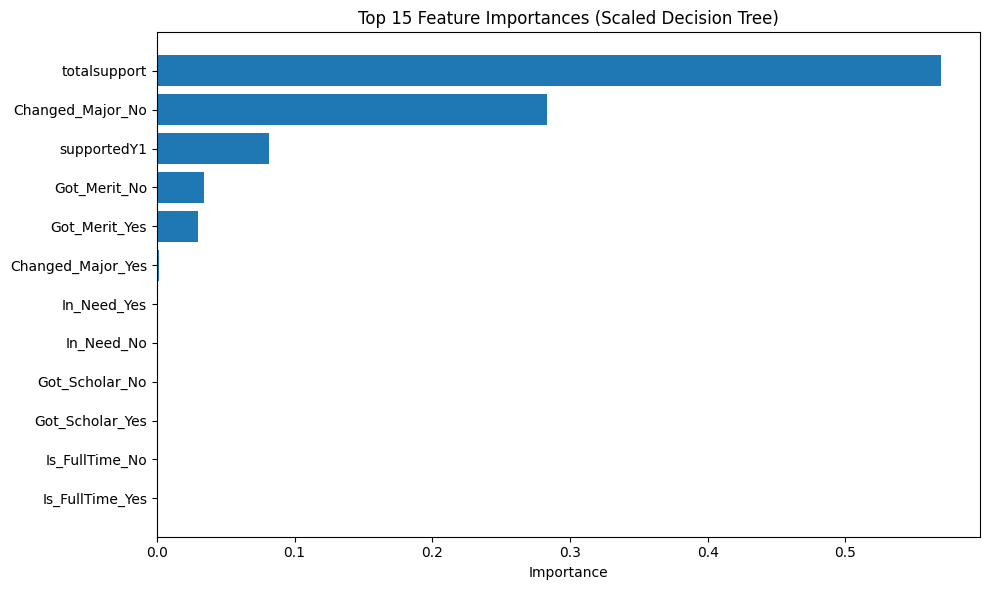

In [50]:
# Get clean feature names
feature_names_scaled = [
    name.split('__')[-1] for name in tree_scaled.named_steps['preprocessor'].get_feature_names_out()
]

# Get importance scores
importances_scaled = tree_scaled.named_steps['classifier'].feature_importances_

# Build DataFrame
feat_imp_df_scaled = pd.DataFrame({
    'Feature': feature_names_scaled,
    'Importance': importances_scaled
}).sort_values(by='Importance', ascending=False)

# Plot Top 15 Features
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df_scaled['Feature'][:15], feat_imp_df_scaled['Importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Scaled Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


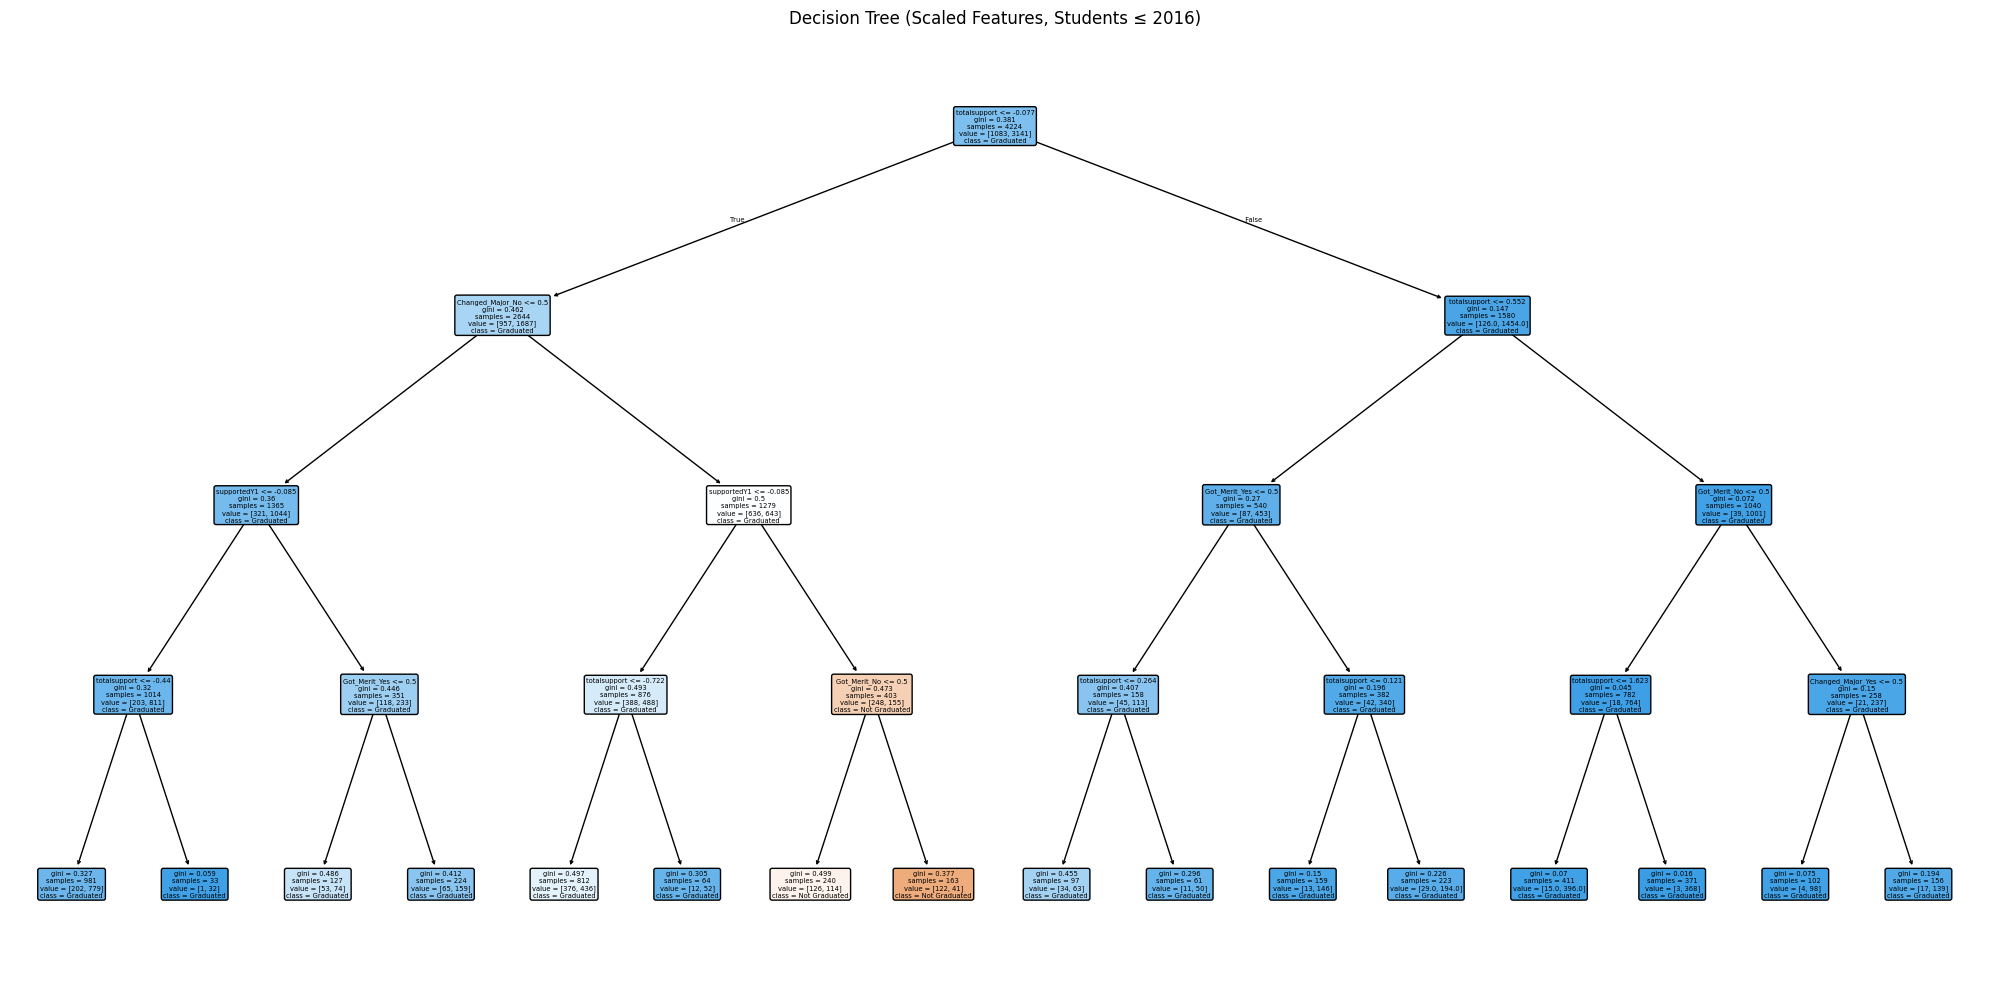

In [51]:
# ----- Plot Tree -----
feature_names_scaled = [name.split('__')[-1] for name in tree_scaled.named_steps['preprocessor'].get_feature_names_out()]

plt.figure(figsize=(20, 10))
plot_tree(
    tree_scaled.named_steps['classifier'],
    feature_names=feature_names_scaled,
    class_names=["Not Graduated", "Graduated"],
    filled=True,
    rounded=True,
    max_depth=4
)
plt.title("Decision Tree (Scaled Features, Students ≤ 2016)")
plt.tight_layout()
plt.savefig("decision_tree_scaled_filtered_2016.png", dpi=1000)
plt.show()

# **Feature 2**

In [52]:
my_features = [
    'MatricTermdescription', 'MatricAcademicYear', 'MatricGenderIPEDS',
    'MatricIPEDSEthnicity', 'Changed_Major', 'supportedY1',
    'Got_Merit', 'Got_Scholar', 'Is_FullTime', 'totalsupport'
]

Accuracy (Scaled): 0.7635
F1 Score (Scaled): 0.8443
ROC AUC (Scaled): 0.7743


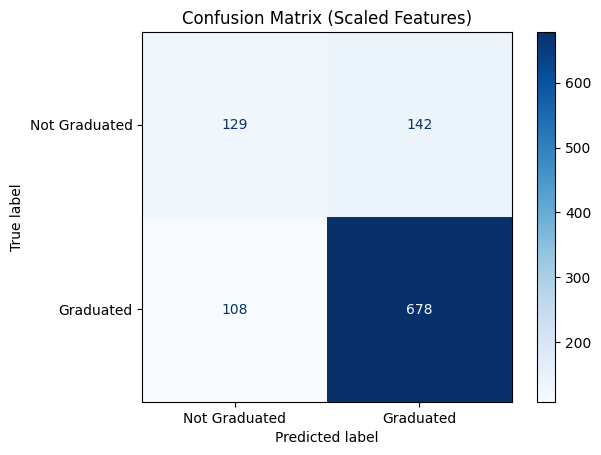

In [53]:
# ----- Prepare Data -----
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, preprocessor_scaled, cat_cols_scaled, num_cols_scaled = prepare_data(
    selected_features=my_features,
    scale_numeric=True
)

# ----- Train Pipeline -----
tree_scaled = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))
])

tree_scaled.fit(X_train_scaled, y_train_scaled)

# ----- Evaluate Model -----
y_pred_scaled = tree_scaled.predict(X_test_scaled)
y_proba_scaled = tree_scaled.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy (Scaled): {accuracy_score(y_test_scaled, y_pred_scaled):.4f}")
print(f"F1 Score (Scaled): {f1_score(y_test_scaled, y_pred_scaled):.4f}")
print(f"ROC AUC (Scaled): {roc_auc_score(y_test_scaled, y_proba_scaled):.4f}")

cm_scaled = confusion_matrix(y_test_scaled, y_pred_scaled)
ConfusionMatrixDisplay(confusion_matrix=cm_scaled, display_labels=["Not Graduated", "Graduated"]).plot(cmap='Blues')
plt.title("Confusion Matrix (Scaled Features)")
plt.show()




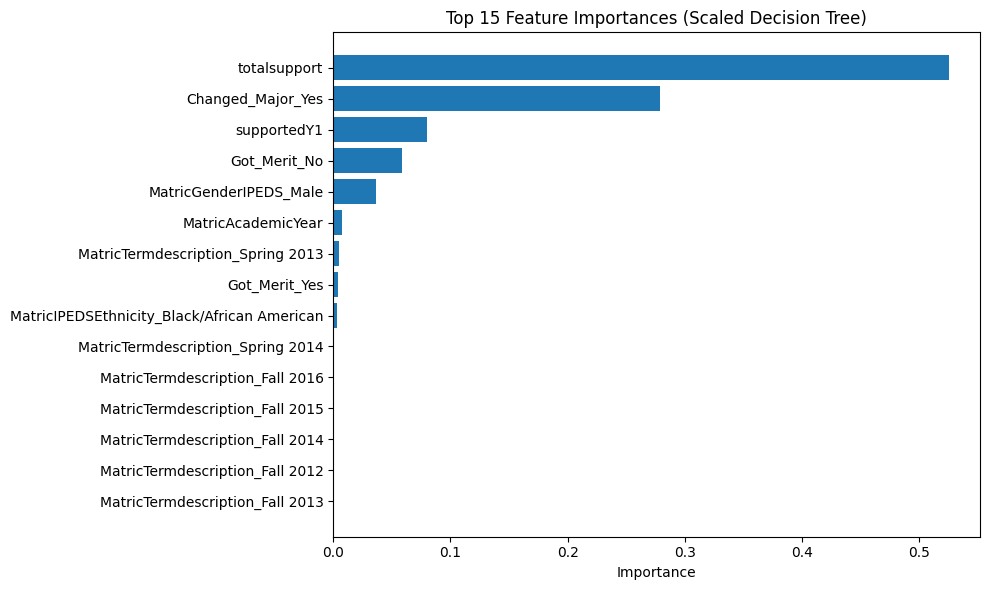

In [54]:
# Get clean feature names
feature_names_scaled = [
    name.split('__')[-1] for name in tree_scaled.named_steps['preprocessor'].get_feature_names_out()
]

# Get importance scores
importances_scaled = tree_scaled.named_steps['classifier'].feature_importances_

# Build DataFrame
feat_imp_df_scaled = pd.DataFrame({
    'Feature': feature_names_scaled,
    'Importance': importances_scaled
}).sort_values(by='Importance', ascending=False)

# Plot Top 15 Features
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df_scaled['Feature'][:15], feat_imp_df_scaled['Importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Scaled Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


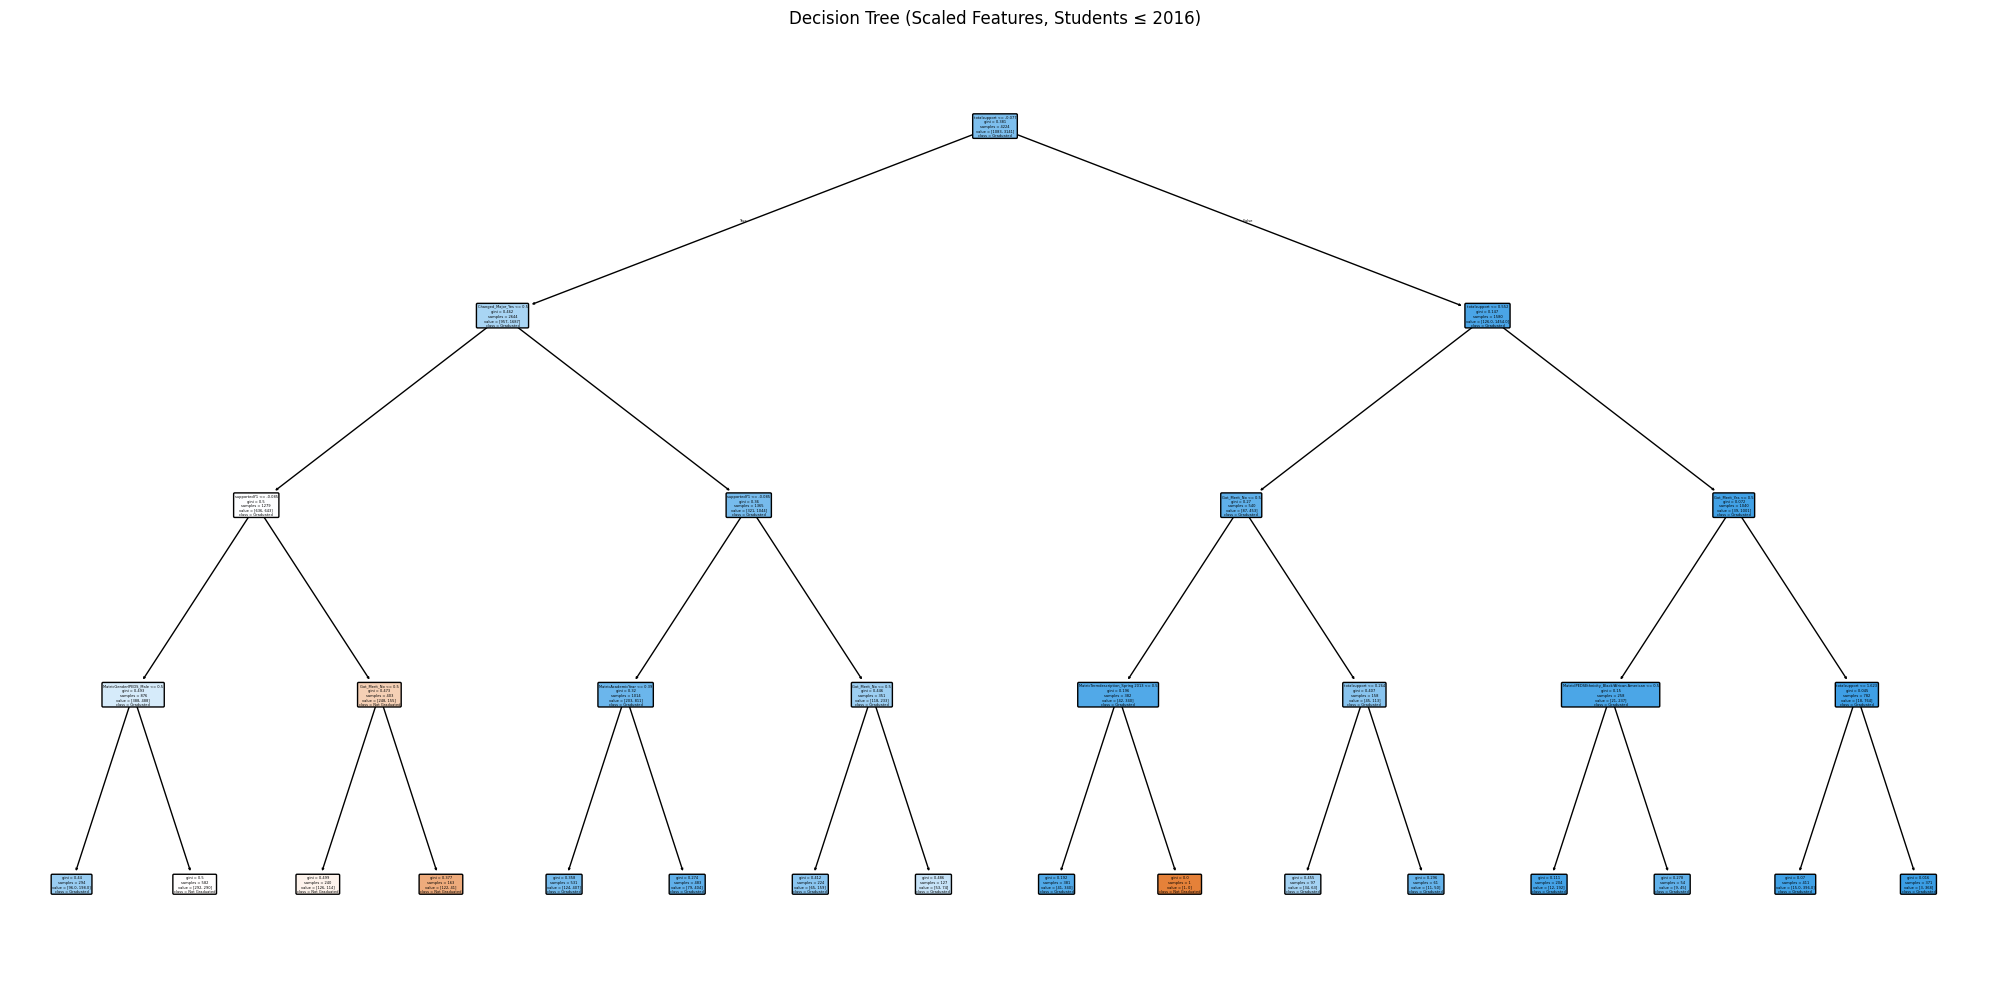

In [55]:
# ----- Plot Tree -----
feature_names_scaled = [name.split('__')[-1] for name in tree_scaled.named_steps['preprocessor'].get_feature_names_out()]

plt.figure(figsize=(20, 10))
plot_tree(
    tree_scaled.named_steps['classifier'],
    feature_names=feature_names_scaled,
    class_names=["Not Graduated", "Graduated"],
    filled=True,
    rounded=True,
    max_depth=4
)
plt.title("Decision Tree (Scaled Features, Students ≤ 2016)")
plt.tight_layout()
plt.savefig("decision_tree_scaled_filtered_2016.png", dpi=1000)
plt.show()

Accuracy (Raw): 0.7635
F1 Score (Raw): 0.8443
ROC AUC (Raw): 0.7743


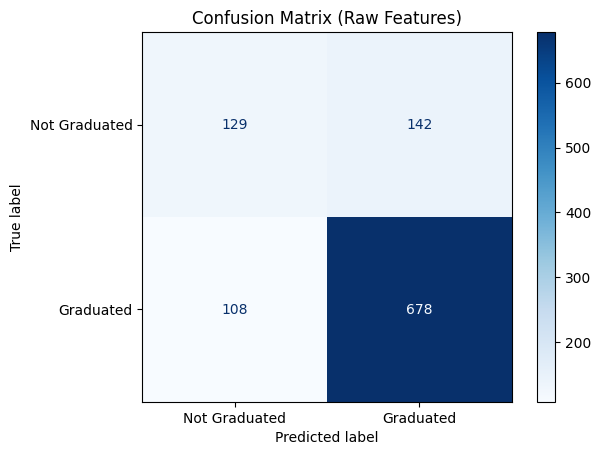

In [56]:
# ----- Prepare Data -----
X_train_raw, X_test_raw, y_train_raw, y_test_raw, preprocessor_raw, cat_cols_raw, num_cols_raw = prepare_data(
    selected_features=my_features,
    scale_numeric=False
)

# ----- Train Pipeline -----
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

tree_raw = Pipeline([
    ('preprocessor', preprocessor_raw),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))
])

tree_raw.fit(X_train_raw, y_train_raw)

# ----- Evaluate Model -----
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

y_pred_raw = tree_raw.predict(X_test_raw)
y_proba_raw = tree_raw.predict_proba(X_test_raw)[:, 1]

print(f"Accuracy (Raw): {accuracy_score(y_test_raw, y_pred_raw):.4f}")
print(f"F1 Score (Raw): {f1_score(y_test_raw, y_pred_raw):.4f}")
print(f"ROC AUC (Raw): {roc_auc_score(y_test_raw, y_proba_raw):.4f}")

cm_raw = confusion_matrix(y_test_raw, y_pred_raw)
ConfusionMatrixDisplay(confusion_matrix=cm_raw, display_labels=["Not Graduated", "Graduated"]).plot(cmap='Blues')
plt.title("Confusion Matrix (Raw Features)")
plt.show()




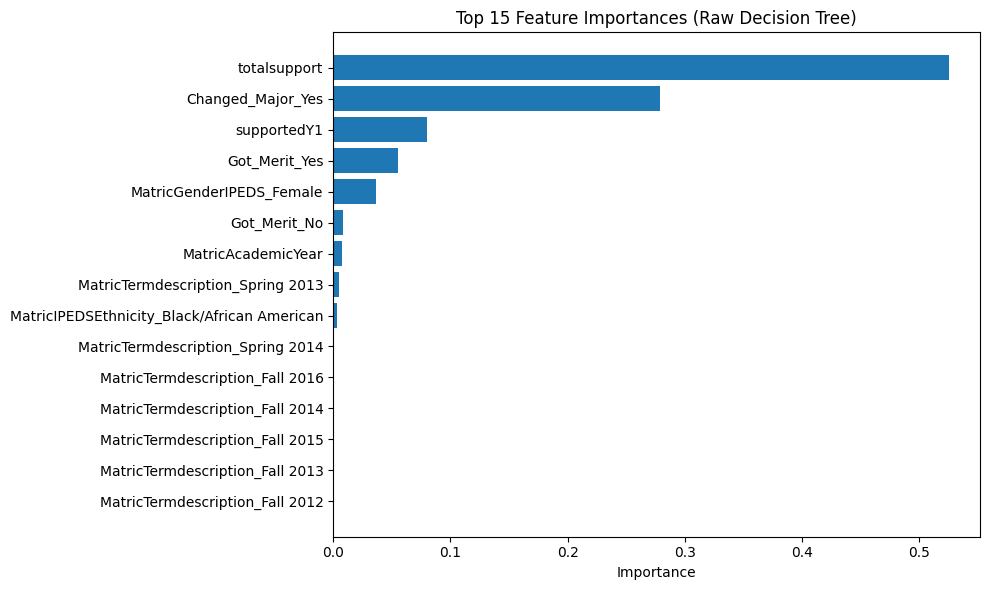

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Get clean feature names
feature_names_raw = [
    name.split('__')[-1] for name in tree_raw.named_steps['preprocessor'].get_feature_names_out()
]

# Get importance scores
importances_raw = tree_raw.named_steps['classifier'].feature_importances_

# Build DataFrame for easy sorting/plotting
feat_imp_df_raw = pd.DataFrame({
    'Feature': feature_names_raw,
    'Importance': importances_raw
}).sort_values(by='Importance', ascending=False)

# Plot Top 15 Features
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df_raw['Feature'][:15], feat_imp_df_raw['Importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Raw Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


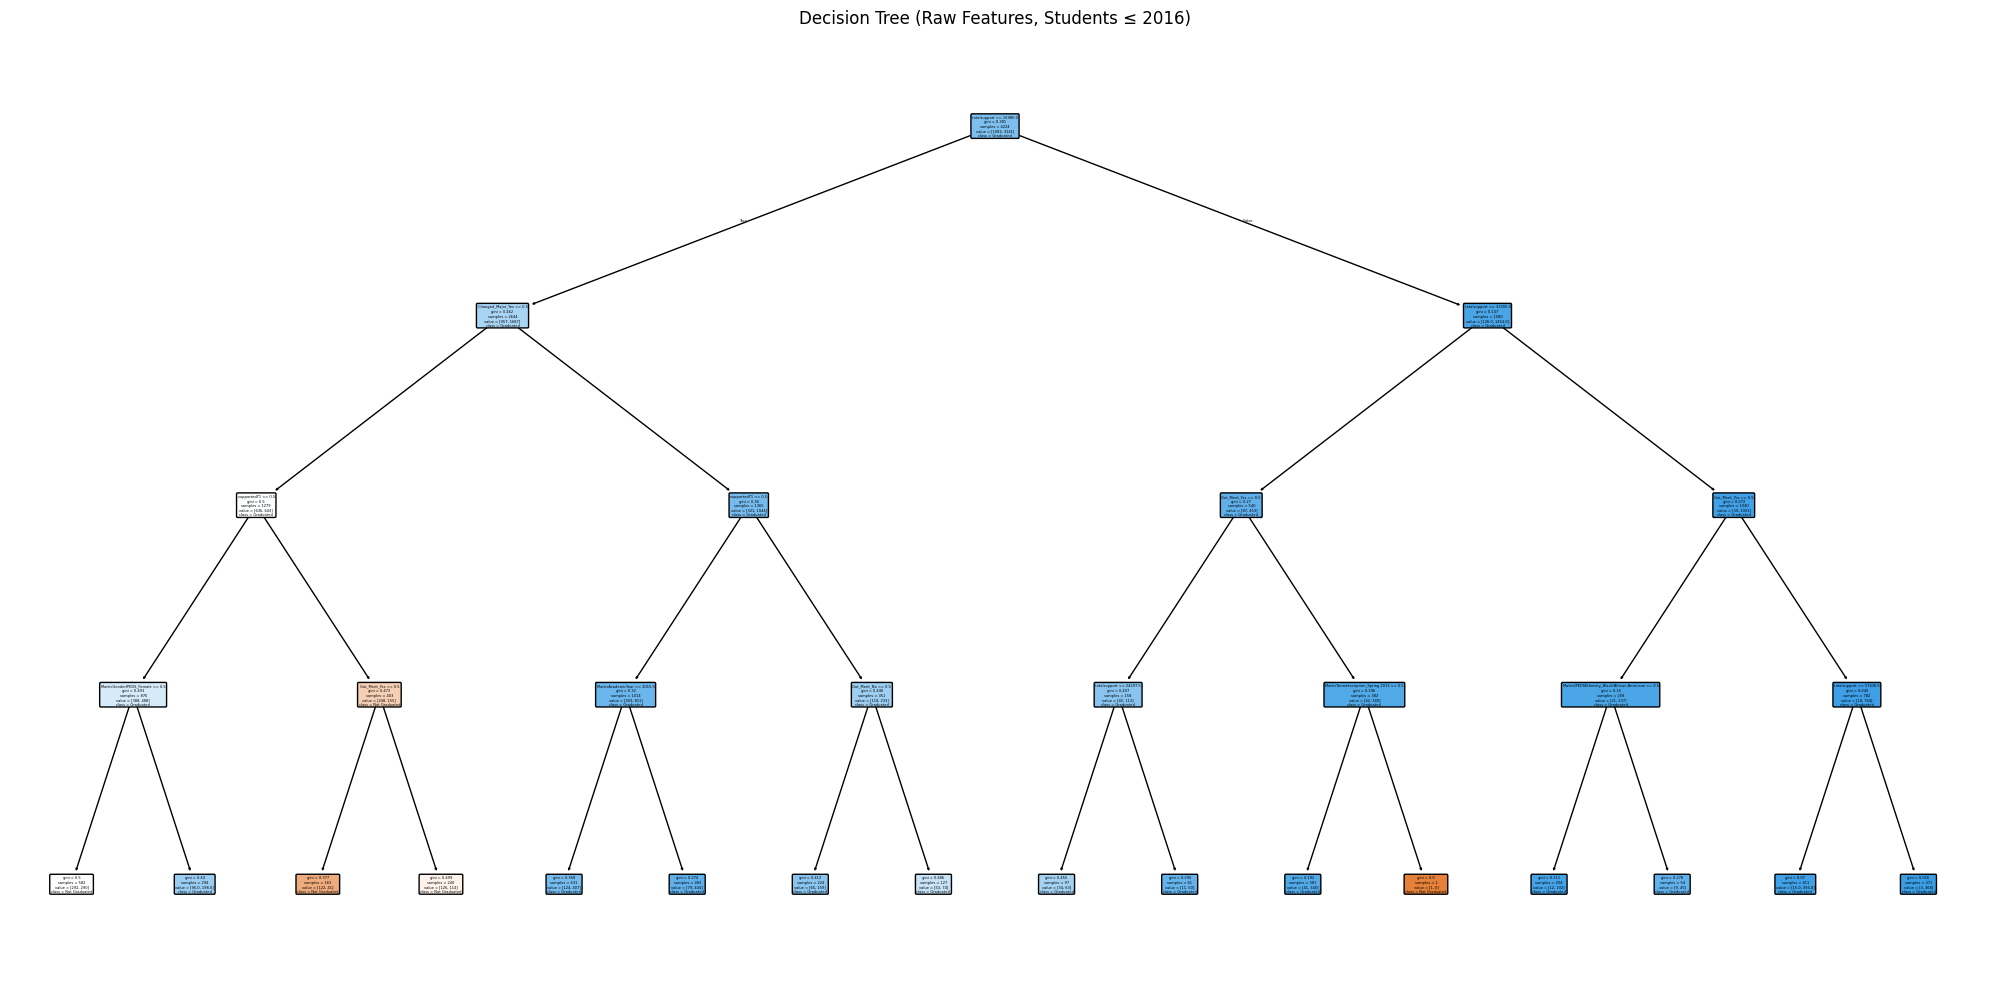

In [58]:
# ----- Plot Tree -----
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

feature_names_raw = [name.split('__')[-1] for name in tree_raw.named_steps['preprocessor'].get_feature_names_out()]

plt.figure(figsize=(20, 10))
plot_tree(
    tree_raw.named_steps['classifier'],
    feature_names=feature_names_raw,
    class_names=["Not Graduated", "Graduated"],
    filled=True,
    rounded=True,
    max_depth=4
)
plt.title("Decision Tree (Raw Features, Students ≤ 2016)")
plt.tight_layout()
plt.savefig("decision_tree_raw_filtered_2016.png", dpi=1000)
plt.show()